# 알고리즘을 교체하며 사용하는 GGMM 실험 노트북

위에서 **알고리즘과 설정**을 정의하고, 아래의 **공통 검사·실험 셀**을 재사용합니다.
이 파일 하나로 Colab/Jupyter에서 실행할 수 있습니다. 옆에 별도 .py를 둘 필요가 없습니다.
파일 저장·PKL·이전 적합 재사용은 하지 않습니다. 실험 셀을 실행할 때마다 새로 적합합니다.

1. 처음에는 준비·알고리즘 정의·공통 함수 셀을 순서대로 실행합니다.
2. **‘실행 방법과 설정’ 셀**에서 `METHODS`와 해당 설정을 바꾸고 그 셀을 다시 실행합니다.
3. 아래 실험 셀을 실행합니다. 같은 셀 안에 표·성분 파라미터·밀도 그림·오차 그림이 나옵니다.
4. 새 알고리즘은 위의 **‘새 알고리즘을 추가하는 자리’**에 정의하고 등록합니다. 공통 평가 코드는 그대로 사용합니다.

기존 BIC 후보 탐색(`bic`), 공동 재적합 분할(`split`), 국소 나무 분할(`tree`),
변분 GGMM(`variational`), 독립 비교 VGM(`vgm`)을 연결했습니다.
기본 실행은 `split`과 `vgm`입니다. 시간이 큰 방법은 이름을 골랐을 때만 적합합니다.
이번 파일은 기존 방법을 비교하는 틀이며 새 적응적 알고리즘의 구현이나 성능 개선을 주장하지 않습니다.

**입력 계약:** 모든 추정기는 `fit(X)`에 X 하나만 받습니다. 참 K·참 파라미터·참 밀도는 사후 평가용입니다.
X를 임의로 나누지 않습니다. `Fit_s`는 초기화와 성분 선택을 포함합니다.
IAE/ISE는 참 밀도를 알고 있는 합성 실험에만 표시합니다. 같은 표본의 LL은 훈련 지표입니다.

**결과 계약:** 정규화된 밀도(가중치·mu·a·b), 수렴 상태, 종료 이유, 선택 점수와 경로를 반환합니다.
수렴·K 탐색 완료·상한 도달을 구분하고 실패한 방법도 표에서 지우지 않습니다.
그림의 영문 표기는 한글 폰트 경고를 피하기 위한 것입니다. 변수와 주석 설명은 한국어입니다.


## 1. 공통 입출력 형식

In [22]:
# 준비: 공통 결과/검사 형식만 정의합니다. 적합은 하지 않습니다.
from dataclasses import dataclass, field, asdict
from datetime import datetime, timezone
from importlib.metadata import version
from time import perf_counter
from typing import Any, Callable
from copy import deepcopy
import platform
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.legendre import leggauss
from scipy.stats import gennorm
from IPython.display import display
from sklearn.mixture import BayesianGaussianMixture
from threadpoolctl import threadpool_limits

@dataclass
class FitOutput:
    """새 알고리즘도 이 형식으로 결과를 반환하면 공통 실험을 재사용한다.

    density: 정규화된 GGD 혼합밀도. 점수는 알고리즘의 실제 선택 점수다.
    search_complete: 정한 탐색/종료 조건의 완료 여부, 전역 최적 보장이 아니다.
    VB 계열에는 같은 의미의 K 탐색 완료 판정이 없으므로 None을 사용한다.
    """
    density: Any
    converged: bool | None
    stop_reason: str
    search_complete: bool | None = None
    at_cap: bool | None = None
    score_name: str = ""
    score_value: float = np.nan
    density_params: int | None = None
    history: pd.DataFrame = field(default_factory=pd.DataFrame)
    diagnostics: dict = field(default_factory=dict)

@dataclass(frozen=True)
class AlgorithmSpec:
    """factory는 호출 때마다 새 객체, extract는 적합 객체 → FitOutput."""
    label: str
    factory: Callable[[], Any]
    extract: Callable[[Any], FitOutput]
    settings: dict = field(default_factory=dict)
    note: str = ""

@dataclass(frozen=True)
class CheckConfig:
    """알고리즘별 최적화 설정과 분리된 공통 사후 검사 설정."""
    weight_atol: float = 1e-8
    mass_atol: float = 1e-5
    tail_probability: float = 1e-9
    quadrature_atol: float = 1e-7
    quadrature_rtol: float = 1e-5
    max_refinement: int = 12

## 2. 기존 BIC GGMM 정의

In [23]:
# 알고리즘 정의: 기존 BIC 후보 적합. 이 셀에서는 적합하지 않습니다.
"""Independent GGMM estimator with BIC-based component-count selection.

No CDF objective, DKW selection, shape penalty, b upper bound, random
initialization, held-out sample, or fitted GMM input. This is numerical local
maximum likelihood, not a variational Bayesian GGMM or guaranteed global MLE.
"""
from dataclasses import dataclass, asdict
from time import perf_counter
from typing import cast
import numpy as np
from numpy.typing import ArrayLike
from scipy.optimize import minimize, brentq
from scipy.special import gammaln, digamma, logsumexp
from scipy.stats import gennorm


@dataclass(frozen=True)
class GGMMBICConfig:
    max_components: int = 10
    scale_floor_relative: float = 1e-3  # a_min / sample population SD
    max_iter: int = 1500
    ftol: float = 1e-10
    gtol: float = 1e-5


@dataclass(init=False)
class Mixture:
    weights: np.ndarray
    means: np.ndarray
    scales: np.ndarray
    shapes: np.ndarray

    def __init__(self, weights: ArrayLike, means: ArrayLike, scales: ArrayLike, shapes: ArrayLike):
        self.weights = np.asarray(weights, dtype=float)
        self.means = np.asarray(means, dtype=float)
        self.scales = np.asarray(scales, dtype=float)
        self.shapes = np.asarray(shapes, dtype=float)
        self.__post_init__()

    def __post_init__(self):
        for name in ('weights', 'means', 'scales', 'shapes'):
            setattr(self, name, np.asarray(getattr(self, name), float))
        if (self.weights.ndim != 1 or len(self.weights) == 0
                or any(getattr(self, p).shape != self.weights.shape
                       for p in ('means', 'scales', 'shapes'))
                or not all(np.isfinite(getattr(self, p)).all()
                           for p in ('weights', 'means', 'scales', 'shapes'))
                or np.any(self.weights <= 0) or not np.isclose(self.weights.sum(), 1)
                or np.any(self.scales <= 0) or np.any(self.shapes <= 0)):
            raise ValueError('Invalid mixture parameters.')

    @property
    def k(self):
        return len(self.weights)

    @property
    def sigmas(self):
        q = 1 / self.shapes
        with np.errstate(over='ignore'):
            return np.exp(np.log(self.scales) + .5 * (
                gammaln(1 + 3*q) - gammaln(1 + q) - np.log(3.)))

    def component_logpdf(self, x):
        return component_terms(np.asarray(x).reshape(-1), self.means,
                               np.log(self.scales), np.log(self.shapes))[0]

    def logpdf(self, x):
        return cast(np.ndarray, logsumexp(self.component_logpdf(x) + np.log(self.weights), axis=1))

    def pdf(self, x):
        return np.exp(self.logpdf(x))

    def cdf(self, x):
        # The power may overflow in distant tails; the limiting CDF is 0 or 1.
        with np.errstate(over='ignore'):
            return (gennorm.cdf(np.asarray(x).reshape(-1, 1), self.shapes,
                                loc=self.means, scale=self.scales) * self.weights).sum(axis=1)

    def component_ppf(self, p, labels):
        labels = np.asarray(labels, int)
        return gennorm.ppf(p, self.shapes[labels], loc=self.means[labels],
                           scale=self.scales[labels])

    def payload(self):
        return {p: getattr(self, p).tolist() for p in ('weights','means','scales','shapes')}

    def formula(self, digits=6):
        """g(x;mu,a,b) parameterization; rounded for display only."""
        f = lambda v: format(float(v), f'.{digits}g')
        return ' + '.join(f'{f(w)} g(x; {f(m)}, {f(a)}, {f(b)})'
                         for w,m,a,b in zip(self.weights,self.means,self.scales,self.shapes))


def unpack(theta, k):
    logits = np.r_[theta[:k-1], 0.]
    lw = logits - cast(float, logsumexp(logits))
    return lw, theta[k-1:2*k-1], theta[2*k-1:3*k-1], theta[3*k-1:]


def pack(model):
    return np.r_[np.log(model.weights[:-1]/model.weights[-1]), model.means,
                 np.log(model.scales), np.log(model.shapes)]


def component_terms(x, mu, la, eta):
    with np.errstate(over='raise', invalid='raise', under='ignore'):
        b, q = np.exp(eta), np.exp(-eta)
        if np.any(b == 0) or np.any(q == 0):
            raise FloatingPointError('Shape cannot be represented.')
        norm = -np.log(2.) - la - gammaln(1 + q)
        dc = q * digamma(1 + q)
    if not np.isfinite(norm).all() or not np.isfinite(dc).all():
        raise FloatingPointError('Shape normalizer cannot be represented.')
    delta = x[:, None] - mu
    with np.errstate(divide='ignore', over='ignore', invalid='ignore', under='ignore'):
        lr = np.log(np.abs(delta)) - la
        lt = b * lr
        lp = norm - np.exp(lt)
    if np.isnan(lp).any():
        raise FloatingPointError('Invalid component density.')
    return lp, delta, lr, lt, dc


def nll_gradient(theta, x, k):
    """Mean NLL and exact derivatives where location derivatives exist.

    For b<=1, x=mu is nonsmooth; a zero location subgradient/convention is
    used at exact equality and this event is reported. No exponent clipping.
    """
    lw, mu, la, eta = unpack(theta, k)
    lp, delta, lr, lt, dc = component_terms(x, mu, la, eta)
    joint = lp + lw
    denom = cast(np.ndarray, logsumexp(joint, axis=1))
    if not np.isfinite(denom).all():
        raise FloatingPointError('Nonfinite mixture log density at an observation.')
    log_r = joint - denom[:, None]
    r = np.exp(log_r)
    with np.errstate(over='raise', invalid='raise', divide='ignore', under='ignore'):
        valid = np.isfinite(joint) & np.isfinite(lt)
        log_rbt = np.full_like(log_r, -np.inf)
        np.add(log_r + eta, lt, out=log_rbt, where=valid)
        rbt = np.exp(log_rbt)
        log_location = np.full_like(log_rbt, -np.inf)
        np.subtract(log_rbt, np.log(np.abs(delta)), out=log_location, where=delta != 0)
        location = np.sign(delta)*np.exp(log_location)
        shape_term = np.zeros_like(rbt)
        np.multiply(rbt, lr, out=shape_term, where=rbt != 0)
        grad = np.r_[np.exp(lw[:-1])-r.mean(axis=0)[:-1], -location.mean(axis=0),
                     (r-rbt).mean(axis=0), (shape_term-r*dc).mean(axis=0)]
    if not np.isfinite(grad).all():
        raise FloatingPointError('Nonfinite likelihood derivative.')
    return float(-denom.mean()), grad


def initial_shape(group):
    """Match mean absolute deviation / SD; fallback only if moment equation fails.

    The theoretical ratio increases from 0 to sqrt(3)/2. A finite sample's
    moment ratio can lie outside that interval. The b=2 fallback is a starting
    point, not a shape restriction or representative-shape assertion.
    """
    mu, sd = float(np.mean(group)), float(np.std(group))
    ratio = float(np.mean(np.abs(group-mu))/sd) if sd > 0 else np.nan
    if len(group) < 4 or not 0 < ratio < np.sqrt(3)/2:
        return 2., True
    def residual(eta):
        q = np.exp(-eta)
        return .5*np.log(3)-np.log(2)+gammaln(1+2*q)-.5*(
            gammaln(1+q)+gammaln(1+3*q))-np.log(ratio)
    lo, hi = -1., 1.
    while residual(lo) > 0 and lo > -16:
        lo -= 1
    while residual(hi) < 0 and hi < 24:
        hi += 1
    if residual(lo) * residual(hi) > 0:
        return 2., True
    return float(np.exp(cast(float, brentq(residual, lo, hi)))), False


def initializations(x, k, floor):
    """Two deterministic partitions, no density model fitted during initialization."""
    quantile = np.minimum(np.arange(len(x))*k//len(x), k-1)
    centers = np.quantile(x, (np.arange(k)+.5)/k)
    labels = None
    for _ in range(100):
        distance = (x[:, None]-centers)**2
        new = distance.argmin(axis=1)
        counts = np.bincount(new, minlength=k)
        for j in np.flatnonzero(counts == 0):
            residual = distance[np.arange(len(x)), new].copy()
            residual[counts[new] <= 1] = -np.inf
            i = int(np.argmax(residual))
            counts[new[i]] -= 1
            new[i] = j
            counts[j] += 1
        if labels is not None and np.array_equal(new, labels):
            break
        labels = new
        centers = np.array([x[labels == j].mean() for j in range(k)])
    assert labels is not None
    partitions = [('quantile', quantile)]
    if not np.array_equal(labels, quantile):
        partitions.append(('lloyd', labels))
    for name, groups in partitions:
        parts = [x[groups == j] for j in range(k)]
        bs = [initial_shape(p) for p in parts]
        b = np.array([t[0] for t in bs])
        sigma = np.array([max(p.std(), floor) for p in parts])
        la = np.log(sigma) + .5*(np.log(3)+gammaln(1+1/b)-gammaln(1+3/b))
        a = np.exp(np.maximum(la, np.log(floor)))
        yield name, Mixture(np.array([len(p) for p in parts])/len(x),
                            np.array([p.mean() for p in parts]), a, b), sum(t[1] for t in bs)


class GGMMBICEstimator:
    def __init__(self, config=None):
        self.config = config or GGMMBICConfig()

    def fit(self, X):
        # Reusing this estimator must never expose a previous selected density
        # after an invalid or interrupted fit.
        self.__dict__ = {'config': self.config, 'fit_status_': 'running'}
        cfg = self.config
        x = np.asarray(X, float)
        if x.ndim == 2 and x.shape[1] == 1:
            x = x[:, 0]
        if x.ndim != 1 or len(x) < 4 or not np.isfinite(x).all():
            raise ValueError('Provide one finite continuous sample, with at least four observations.')
        if (not isinstance(cfg.max_components, int) or cfg.max_components < 1
                or not np.isfinite(cfg.scale_floor_relative) or cfg.scale_floor_relative <= 0
                or cfg.max_iter < 1 or not 0 < cfg.ftol < 1 or not 0 < cfg.gtol < 1):
            raise ValueError('Invalid configuration.')
        start = perf_counter()
        self.center_, self.unit_ = float(np.mean(x)), float(np.std(x))
        if not np.isfinite(self.unit_) or self.unit_ <= 0:
            raise ValueError('Constant or unrepresentable range: use a separate constant-column handler.')
        z = np.sort((x-self.center_)/self.unit_)
        if not np.isfinite(z).all():
            raise ValueError('Rescale the observations before fitting.')
        self.a_min_ = cfg.scale_floor_relative*self.unit_
        self.starts_, self.selection_, self.models_ = [], [], {}
        upper = min(cfg.max_components, len(np.unique(z)), len(z))
        previous_ll = -np.inf
        for k in range(1, upper+1):
            tick = perf_counter()
            bounds = [(None, None)]*(2*k-1) + [(np.log(cfg.scale_floor_relative), None)]*k + [(None, None)]*k
            candidates = []
            init_tick = perf_counter()
            starts = list(initializations(z, k, cfg.scale_floor_relative))
            initialization_seconds = perf_counter()-init_tick
            for name, initial, fallback_count in starts:
                start_tick = perf_counter()
                best = [np.inf, None]
                rejected = [0]
                def objective(theta):
                    try:
                        value, grad = nll_gradient(theta, z, k)
                        if value < best[0]:
                            best[:] = value, theta.copy()
                        return value, grad
                    except (FloatingPointError, ValueError):
                        rejected[0] += 1
                        return np.inf, np.zeros_like(theta)
                theta0 = pack(initial)
                objective(theta0)
                optimize_tick = perf_counter()
                opt = minimize(objective, theta0, jac=True, method='L-BFGS-B', bounds=bounds,
                               options=dict(maxiter=cfg.max_iter, ftol=cfg.ftol, gtol=cfg.gtol, maxls=50))
                optimize_seconds = perf_counter()-optimize_tick
                timing = dict(optimization_seconds=optimize_seconds,
                              nfev=int(getattr(opt, 'nfev', -1)))
                theta = best[1]
                if theta is None:
                    self.starts_.append(dict(K=k, start=name, finite=False, converged=False,
                        message='No finite likelihood', rejected_steps=rejected[0],
                        seconds=perf_counter()-start_tick, **timing))
                    continue
                value, grad = nll_gradient(theta, z, k)
                # Returning the best visited point avoids discarding a better finite trial.
                # If it differs from the optimizer endpoint, do not claim convergence.
                at_endpoint = bool(np.allclose(theta, opt.x, rtol=1e-10, atol=1e-10))
                for j in range(2*k-1, 3*k-1):
                    if theta[j] <= np.log(cfg.scale_floor_relative)+1e-8 and grad[j] > 0:
                        grad[j] = 0
                lw, mu, la, eta = unpack(theta, k)
                order = np.argsort(mu)
                try:
                    model = Mixture(np.exp(lw)[order], (self.center_+self.unit_*mu)[order],
                                    (self.unit_*np.exp(la))[order], np.exp(eta)[order])
                except ValueError as exc:
                    self.starts_.append(dict(K=k, start=name, finite=False, converged=False,
                        message=f'Unrepresentable final mixture: {exc}', rejected_steps=rejected[0],
                        seconds=perf_counter()-start_tick, **timing))
                    continue
                ll = float(-len(z)*(value+np.log(self.unit_)))
                row = dict(K=k, start=name, finite=True, log_likelihood=ll,
                           BIC=-2*ll+(4*k-1)*np.log(len(z)), converged=bool(opt.success and at_endpoint),
                           projected_gradient=float(np.max(np.abs(grad))), iterations=int(opt.nit),
                           message=str(opt.message), best_is_endpoint=at_endpoint,
                           rejected_steps=rejected[0], initial_shapes=initial.shapes.tolist(),
                           moment_fallback_components=int(fallback_count),
                           a_floor_hits=int(np.sum(model.scales <= self.a_min_*(1+1e-6))),
                           max_b=float(model.shapes.max()), min_b=float(model.shapes.min()),
                           nonsmooth_coincidences=int(np.sum((z[:, None] == mu) & (np.exp(eta) <= 1))))
                row.update(seconds=perf_counter()-start_tick, **timing)
                self.starts_.append(row)
                candidates.append((row, model))
            if not candidates:
                self.selection_.append(dict(K=k, finite=False, converged=False, BIC=np.inf,
                    log_likelihood=np.nan, seconds=perf_counter()-tick,
                    initialization_seconds=initialization_seconds, starts_count=len(starts)))
                continue
            row, model = min(candidates, key=lambda item: item[0]['BIC'])
            row = row.copy()
            row.update(seconds=perf_counter()-tick,
                       initialization_seconds=initialization_seconds, starts_count=len(starts),
                       likelihood_decreased=bool(row['log_likelihood'] < previous_ll-1e-5))
            previous_ll = max(previous_ll, row['log_likelihood'])
            self.models_[k] = model
            self.selection_.append(row)
        finite = [r for r in self.selection_ if r['finite']]
        if not finite:
            raise RuntimeError('All fits failed; inspect starts_.')
        winner = min(finite, key=lambda r: r['BIC'])
        self.n_components_ = winner['K']
        self.density_ = self.models_[self.n_components_]
        for r in self.selection_:
            r['delta_BIC'] = r['BIC']-winner['BIC']
            r['selected'] = r['K'] == self.n_components_
        self.diagnostics_ = dict(n=len(x), selected_K=self.n_components_, config=asdict(cfg),
            effective_Kmax=upper,
            scale_floor_original_units=self.a_min_, selected_converged=winner['converged'],
            any_K_nonconverged=any(not r['converged'] for r in self.selection_),
            any_likelihood_decrease=any(r.get('likelihood_decreased',False) for r in self.selection_),
            selected_at_Kmax=self.n_components_ == upper,
            status='numerical_local_fit; no global optimum or true-K guarantee', seconds=perf_counter()-start)
        self.fit_status_ = 'complete'
        return self

    def predict_proba(self, X):
        joint = self.density_.component_logpdf(X) + np.log(self.density_.weights)
        denominator = cast(np.ndarray, logsumexp(joint, axis=1))
        if not np.isfinite(denominator).all():
            raise FloatingPointError('Posterior probabilities cannot be represented for these values.')
        return np.exp(joint-denominator[:, None])


## 3. 기존 공동 분할 GGMM 정의

In [24]:
# 알고리즘 정의: 기존 공동 재적합 분할. 이 셀에서는 적합하지 않습니다.
"""Grow an independent GGMM by deterministic component splits accepted by BIC.

Only X enters fit. No variational posterior, independent K grid, truth, GMM
initialization, random starts, or pruning threshold. Uses the established GGD
likelihood and its analytic gradient; every candidate reoptimizes all parameters.
This is a greedy numerical research implementation, not a global K optimizer.
"""
from dataclasses import dataclass, asdict
from time import perf_counter
from typing import Any, cast
import numpy as np
from scipy.optimize import minimize
from scipy.special import logsumexp


@dataclass(frozen=True)
class SplitBICConfig:
    safety_max_components: int = 30  # compute guard, not a K candidate list
    scale_floor_relative: float = 1e-3
    max_iter: int = 1500
    retry_multiplier: int = 2
    ftol: float = 1e-10
    gtol: float = 1e-5
    bic_tolerance: float = 1e-6  # improvement must exceed numerical tolerance
    min_split_mass: float = 8.  # proposal eligibility, not a final weight constraint
    split_methods: tuple = ('weighted_median', 'weighted_lloyd')


def bic_score(log_likelihood, k, n):
    return float(-2*log_likelihood+(4*k-1)*np.log(n))


def duplicate_component(model, parent):
    """Exact density-preserving K+1 embedding used ONLY as a diagnostic."""
    keep = np.arange(model.k) != parent
    return Mixture(np.r_[model.weights[keep], model.weights[parent]/2, model.weights[parent]/2],
        np.r_[model.means[keep], model.means[parent], model.means[parent]],
        np.r_[model.scales[keep], model.scales[parent], model.scales[parent]],
        np.r_[model.shapes[keep], model.shapes[parent], model.shapes[parent]])


def responsibilities(x, model):
    joint = model.component_logpdf(x)+np.log(model.weights)
    norm = np.asarray(logsumexp(joint,axis=1),dtype=float)
    if not np.isfinite(norm).all():
        raise FloatingPointError('Nonfinite mixture log density in split proposal.')
    return np.exp(joint-norm[:,None])


def weighted_quantile(x, weights, p):
    positive = weights > 0
    xx, ww = np.asarray(x)[positive], np.asarray(weights)[positive]
    if not len(xx) or ww.sum() <= 0:
        raise ValueError('Empty weighted group.')
    order = np.argsort(xx,kind='stable')
    xx,ww = xx[order],ww[order]
    centers = (np.cumsum(ww)-.5*ww)/ww.sum()
    return float(np.interp(p,centers,xx))


def weighted_component(x, weights, floor):
    """Moment-based child start; not claimed to be weighted MLE."""
    positive = weights > 0
    xx,ww = np.asarray(x)[positive],np.asarray(weights)[positive]
    total = float(ww.sum())
    if total <= 0 or len(np.unique(xx)) < 2:
        raise ValueError('Child needs two distinct observations with positive responsibility.')
    ww = ww/total
    mu = float(ww@xx)
    sd = float(np.sqrt(ww@((xx-mu)**2)))
    # Use the established ratio equation, but with weighted moments.
    ratio = float(ww@np.abs(xx-mu)/sd) if sd > 0 else np.nan
    fallback = not (0 < ratio < np.sqrt(3)/2)
    if fallback:
        shape = 2.
    else:
        from scipy.optimize import brentq
        from scipy.special import gammaln
        def f(eta):
            q = np.exp(-eta)
            return (.5*np.log(3)-np.log(2)+gammaln(1+2*q)
                    -.5*(gammaln(1+q)+gammaln(1+3*q))-np.log(ratio))
        lo,hi = -1.,1.
        while f(lo)>0 and lo>-16: lo-=1
        while f(hi)<0 and hi<24: hi+=1
        if f(lo)*f(hi) <= 0:
            shape = float(np.exp(cast(float,brentq(f,lo,hi))))
        else:
            shape,fallback = 2.,True
    from scipy.special import gammaln
    la = np.log(max(sd,floor))+.5*(np.log(3)+gammaln(1+1/shape)-gammaln(1+3/shape))
    scale = max(float(np.exp(la)),floor)
    return mu,scale,shape,int(fallback)


def split_initializations(x, model, parent, floor, methods=('weighted_median','weighted_lloyd'),
                          min_mass=8.):
    """Split one parent's responsibilities into two groups; keep other starts.

    Parent mass is distributed between children exactly. Child parameters are
    sample-derived starts and subsequently free in the full likelihood fit.
    """
    r = responsibilities(x,model)[:,parent]
    if r.sum() < min_mass:
        return []
    output,seen = [],[]
    for method in methods:
        if method == 'weighted_median':
            left = np.asarray(x) <= weighted_quantile(x,r,.5)
        elif method == 'weighted_lloyd':
            centers = np.array([weighted_quantile(x,r,.25),weighted_quantile(x,r,.75)])
            old = None
            left = np.zeros(len(x),dtype=bool)
            for _ in range(100):
                left = (np.asarray(x)-centers[0])**2 <= (np.asarray(x)-centers[1])**2
                if not r[left].sum()>0 or not r[~left].sum()>0: break
                if old is not None and np.array_equal(left,old): break
                centers = np.array([r[left]@np.asarray(x)[left]/r[left].sum(),
                    r[~left]@np.asarray(x)[~left]/r[~left].sum()])
                old = left.copy()                   
        else:
            raise ValueError('Unknown split method.')
        if any(np.array_equal(left,mask) for mask in seen): continue
        seen.append(left.copy())
        child_weights = [r*left,r*~left]
        if min(v.sum() for v in child_weights) < min_mass/2: continue
        try:
            children = [weighted_component(x,w,floor) for w in child_weights]
        except (ValueError,FloatingPointError,OverflowError):
            continue
        keep = np.arange(model.k) != parent
        child_mass = model.weights[parent]*np.array([v.sum() for v in child_weights])/r.sum()
        initial = Mixture(np.r_[model.weights[keep],child_mass],
            np.r_[model.means[keep],[v[0] for v in children]],
            np.r_[model.scales[keep],[v[1] for v in children]],
            np.r_[model.shapes[keep],[v[2] for v in children]])
        output.append((method,initial,sum(v[3] for v in children)))
    return output


def optimize_start(x, initial, config) -> tuple[Mixture | None,dict[str,Any]]:
    """Full constrained local likelihood fit, with best-point status disclosed."""
    started = perf_counter()
    k = initial.k
    bounds = [(None,None)]*(2*k-1)+[(np.log(config.scale_floor_relative),None)]*k+[(None,None)]*k
    theta0 = pack(initial)
    best = [np.inf,None]
    rejected = 0
    def objective(theta):
        nonlocal rejected
        try:
            value,grad = nll_gradient(theta,x,k)
            if value < best[0]: best[:] = [value,theta.copy()]
            return value,grad
        except (FloatingPointError,ValueError,OverflowError):
            rejected += 1
            return np.inf,np.zeros_like(theta)
    objective(theta0)
    total_iterations,total_nfev = 0,0
    attempt,opt,endpoint,stationary = 0,None,False,False
    gradient_check_tolerance = 10*config.gtol
    def projected_gradient_at(theta):
        _,grad = nll_gradient(theta,x,k)
        for j in range(2*k-1,3*k-1):
            if theta[j] <= np.log(config.scale_floor_relative)+1e-8 and grad[j]>0: grad[j]=0
        return float(np.max(np.abs(grad)))
    for attempt in range(1,3):
        limit = config.max_iter*(1 if attempt == 1 else config.retry_multiplier)
        opt = minimize(objective,theta0,jac=True,method='L-BFGS-B',bounds=bounds,
            options=dict(maxiter=limit,ftol=config.ftol,gtol=config.gtol,maxls=50))
        total_iterations += int(opt.nit)
        total_nfev += int(opt.nfev)
        theta = best[1]
        endpoint = theta is not None and np.allclose(theta,opt.x,rtol=1e-10,atol=1e-10)
        try:
            stationary = theta is not None and projected_gradient_at(theta) <= gradient_check_tolerance
        except (FloatingPointError,ValueError,OverflowError):
            stationary = False
        if opt.success and endpoint and stationary: break
        if attempt == 1 and config.retry_multiplier > 1 and theta is not None:
            theta0 = theta.copy()
        else: break
    if opt is None:
        raise RuntimeError('Optimizer was not invoked.')
    base = dict(finite=False,converged=False,iterations=total_iterations,nfev=total_nfev,
        attempts=attempt,message=str(opt.message),best_is_endpoint=bool(endpoint),
        solver_success=bool(opt.success),stationarity_checked=bool(stationary),
        gradient_check_tolerance=gradient_check_tolerance,
        rejected_steps=rejected,seconds=perf_counter()-started)
    if best[1] is None:
        return None,dict(base,log_likelihood=np.nan,BIC=np.inf)
    theta = best[1]
    try:
        value,grad = nll_gradient(theta,x,k)
        for j in range(2*k-1,3*k-1):
            if theta[j] <= np.log(config.scale_floor_relative)+1e-8 and grad[j]>0: grad[j]=0
        lw,mu,la,eta = unpack(theta,k)
        order = np.argsort(mu,kind='stable')
        model = Mixture(np.exp(lw)[order],mu[order],np.exp(la)[order],np.exp(eta)[order])
        ll = float(-len(x)*value)
    except (FloatingPointError,ValueError,OverflowError) as exc:
        return None,dict(base,log_likelihood=np.nan,BIC=np.inf,message=str(exc))
    base.update(finite=True,converged=bool(opt.success and endpoint and stationary),
        log_likelihood=ll,BIC=bic_score(ll,k,len(x)),
        projected_gradient=float(np.max(np.abs(grad))),
        a_floor_hits=int(np.sum(model.scales<=config.scale_floor_relative*(1+1e-6))),
        min_b=float(model.shapes.min()),max_b=float(model.shapes.max()),
        seconds=perf_counter()-started)
    return model,base


class SplitBICGGMM:
    def __init__(self,config=None):
        self.config = config or SplitBICConfig()

    def fit(self,X):
        cfg = self.config
        self.__dict__ = {'config':cfg,'fit_status_':'running'}
        try:
            return self._fit(X)
        except Exception:
            self.__dict__ = {'config':cfg,'fit_status_':'failed'}
            raise

    def _fit(self,X):
        cfg = self.config
        begin = perf_counter()
        x = np.array(X,dtype=float,copy=True)
        if x.ndim == 2 and x.shape[1] == 1: x=x[:,0]
        if x.ndim != 1 or len(x)<4 or not np.isfinite(x).all() or np.std(x)<=0:
            raise ValueError('X must be a finite nonconstant continuous column, n>=4.')
        if (any(not isinstance(v,(int,np.integer)) or isinstance(v,(bool,np.bool_)) or v<1
                for v in [cfg.safety_max_components,cfg.max_iter,cfg.retry_multiplier])
            or not 0<cfg.ftol<1 or not 0<cfg.gtol<1
            or not np.isfinite(cfg.scale_floor_relative) or cfg.scale_floor_relative<=0
            or not np.isfinite(cfg.bic_tolerance) or cfg.bic_tolerance<0
            or not np.isfinite(cfg.min_split_mass) or cfg.min_split_mass<=0
            or not cfg.split_methods
            or any(v not in ('weighted_median','weighted_lloyd') for v in cfg.split_methods)):
            raise ValueError('Invalid split-BIC settings.')
        self.center_,self.unit_ = float(x.mean()),float(x.std())
        z = np.sort((x-self.center_)/self.unit_)
        if not np.isfinite(z).all(): raise ValueError('Input range cannot be standardized.')
        self.input_x_ = x.copy()
        self.input_x_.setflags(write=False)
        mu,a,b,fallback = weighted_component(z,np.ones(len(z)),cfg.scale_floor_relative)
        current,base = optimize_start(z,Mixture([1.],[mu],[a],[b]),cfg)
        if current is None or not base['converged']:
            raise RuntimeError('Initial one-component fit did not converge: '+str(base))
        shift = len(x)*np.log(self.unit_)
        self.candidates_,self.path_,self.models_,self.skipped_splits_ = [],[],{},[]
        def restore(model):
            return Mixture(model.weights,self.center_+self.unit_*model.means,
                           self.unit_*model.scales,model.shapes)
        def reported(row):
            row = dict(row)
            row['log_likelihood'] -= shift
            row['BIC'] += 2*shift
            return row
        accepted = reported(base)
        accepted.update(K=1,split_parent=None,split_method='one_component',
            moment_fallbacks=fallback,step=0,accepted=True)
        self.path_.append(accepted)
        self.models_[1] = restore(current)
        upper = min(cfg.safety_max_components,len(np.unique(z)))
        reason = 'safety_cap_reached'
        search_complete = False
        while current.k < upper:
            stage = current.k
            proposals = []
            failures = 0
            for parent in range(stage):
                exact = duplicate_component(current,parent)
                nesting_error = float(np.max(np.abs(exact.logpdf(z)-current.logpdf(z))))
                starts = split_initializations(z,current,parent,cfg.scale_floor_relative,
                    cfg.split_methods,cfg.min_split_mass)
                if not starts:
                    self.skipped_splits_.append(dict(from_K=stage,split_parent=parent+1,
                        effective_mass=float(responsibilities(z,current)[:,parent].sum()),
                        reason='No valid deterministic split under mass/support proposal rules'))
                for name,initial,fallback in starts:
                    fitted,row = optimize_start(z,initial,cfg)
                    row = reported(row)
                    row.update(step=stage,from_K=stage,K=stage+1,split_parent=parent+1,
                        split_method=name,moment_fallbacks=fallback,
                        nested_density_max_log_error=nesting_error,accepted=False,
                        delta_LL=row['log_likelihood']-accepted['log_likelihood'],
                        delta_BIC=row['BIC']-accepted['BIC'])
                    row['likelihood_below_parent'] = bool(row['finite'] and row['delta_LL'] < -1e-5)
                    self.candidates_.append(row)
                    if fitted is not None and row['converged'] and not row['likelihood_below_parent']:
                        proposals.append((fitted,row))
                    else: failures+=1
            if not proposals:
                reason = 'split_optimization_incomplete' if failures else 'no_eligible_split'
                search_complete = False
                break
            candidate,row = min(proposals,key=lambda item:item[1]['BIC'])
            if row['BIC'] < accepted['BIC']-cfg.bic_tolerance:
                row['accepted'] = True
                current,accepted = candidate,row.copy()
                self.path_.append(accepted)
                self.models_[current.k] = restore(current)
                continue
            reason = 'split_optimization_incomplete' if failures else 'no_BIC_improving_split'
            search_complete = failures == 0
            break
        self.n_components_ = current.k
        self.density_ = restore(current)
        self.converged_ = bool(accepted['converged'])
        self.fit_seconds_ = perf_counter()-begin
        self.stop_reason_ = reason
        self.diagnostics_ = dict(n=len(x),config=asdict(cfg),selected_K=current.k,
            selected_BIC=accepted['BIC'],selected_LL=accepted['log_likelihood'],
            selected_converged=self.converged_,stop_reason=reason,
            searched_splits_at_stop_complete=search_complete,
            at_safety_cap=current.k==upper,
            optimizer_runs=1+len(self.candidates_),
            minimize_calls=int(base['attempts']+sum(r['attempts'] for r in self.candidates_)),
            all_visited_rounds_fully_converged=all(r['converged'] for r in self.candidates_),
            skipped_parent_splits=len(self.skipped_splits_),
            nonconverged_candidates=sum(not r['converged'] for r in self.candidates_),
            failed_candidates=sum(not r['finite'] for r in self.candidates_),
            total_iterations=int(base['iterations']+sum(r['iterations'] for r in self.candidates_)),
            scale_floor_original_units=cfg.scale_floor_relative*self.unit_,
            fitted_K_not_thresholded=True,no_global_K_guarantee=True,
            seconds=self.fit_seconds_)
        self.fit_status_ = 'complete' if search_complete else 'stopped_with_limit_or_unresolved_search'
        return self


## 4. 기존 변분 GGMM 정의

In [25]:
# 알고리즘 정의: 기존 변분 GGMM. 이름 충돌 방지 접두사만 적용했습니다.
"""Independent deterministic variational EM for a truncated DP GGD mixture.

q(v): Beta; q(z): categorical; q(mu): Normal; q(tau): Gamma (shape/rate).
b is a positive point estimate, tau=a**(-b). This is not an exact reproduction
of Amudala's Taylor-approximation algorithm or full Bayes over b.
Only X enters fit. Exported densities are normalized parameter plug-in GGMMs,
not the full posterior predictive density. No BIC search, cache, or file IO.
"""
from dataclasses import dataclass
from time import perf_counter
from typing import cast
import warnings
import numpy as np
from numpy.typing import ArrayLike
from scipy.special import gammaln, digamma, betaln, hyp1f1, logsumexp, xlogy
from scipy.optimize import minimize, brentq
from scipy.stats import gennorm


@dataclass(frozen=True)
class VB_VGGMMConfig:
    max_components: int = 10
    concentration: float = .001
    active_threshold: float = .005
    max_iter: int = 300
    tol: float = 1e-5  # absolute ELBO improvement / n, not LL or gradient tolerance
    inner_max_iter: int = 30
    inner_ftol: float = 1e-8
    mean_prior_sd: float = 3.
    precision_prior_shape: float = 1.
    precision_prior_rate: float = .001
    starts: tuple = ('quantile', 'lloyd')
    fixed_shape: float | None = None


@dataclass(init=False)
class VB_Mixture:
    weights: np.ndarray
    means: np.ndarray
    scales: np.ndarray
    shapes: np.ndarray

    def __init__(self, weights: ArrayLike, means: ArrayLike, scales: ArrayLike, shapes: ArrayLike):
        self.weights = np.asarray(weights, dtype=float).copy()
        self.means = np.asarray(means, dtype=float).copy()
        self.scales = np.asarray(scales, dtype=float).copy()
        self.shapes = np.asarray(shapes, dtype=float).copy()
        if (self.weights.ndim != 1 or not self.weights.size
                or any(getattr(self, k).shape != self.weights.shape
                       for k in ('means', 'scales', 'shapes'))
                or not all(np.isfinite(getattr(self, k)).all()
                           for k in ('weights', 'means', 'scales', 'shapes'))
                or np.any(self.weights < 0) or not np.isclose(self.weights.sum(), 1)
                or np.any(self.scales <= 0) or np.any(self.shapes <= 0)):
            raise ValueError('Invalid mixture parameters.')

    @property
    def k(self):
        return len(self.weights)

    @property
    def sigmas(self):
        return self.scales * np.exp(.5*(gammaln(3/self.shapes)-gammaln(1/self.shapes)))

    def component_logpdf(self, x):
        return np.asarray(gennorm.logpdf(np.asarray(x).reshape(-1, 1),
                        self.shapes, loc=self.means, scale=self.scales), dtype=float)

    def logpdf(self, x):
        with np.errstate(divide='ignore'):
            return np.asarray(logsumexp(self.component_logpdf(x)+np.log(self.weights), axis=1), dtype=float)

    def pdf(self, x):
        return np.exp(self.logpdf(x))

    def cdf(self, x):
        return (gennorm.cdf(np.asarray(x).reshape(-1, 1), self.shapes,
                           loc=self.means, scale=self.scales)*self.weights).sum(axis=1)

    def component_ppf(self, p, labels):
        labels = np.asarray(labels, dtype=int)
        return gennorm.ppf(p, self.shapes[labels], loc=self.means[labels], scale=self.scales[labels])

    def formula(self, digits=6):
        f = lambda v: format(float(v), f'.{digits}g')
        return ' + '.join(f'{f(w)} g(x; {f(m)}, {f(a)}, {f(b)})'
            for w, m, a, b in zip(self.weights, self.means, self.scales, self.shapes))

    def payload(self):
        return {k: getattr(self, k).tolist() for k in ('weights','means','scales','shapes')}


def VB_sample_mixture(truth, n, seed):
    # Same vectorized sampling order as GGMM_BIC.ipynb.
    rng = np.random.default_rng(seed)
    labels = rng.choice(truth.k, size=n, p=truth.weights)
    return np.asarray(gennorm.rvs(truth.shapes[labels], loc=truth.means[labels],
                       scale=truth.scales[labels], random_state=rng), dtype=float)


def VB_normal_log_abs_moment(x, mean, log_sd, b):
    """log E|x-U|**b for U~Normal(mean, exp(2*log_sd)), b>0.

    Exact special-function identity, not Taylor expansion or Monte Carlo.
    Unrepresentable proposals are rejected, not exponent/shape clipped.
    """
    with np.errstate(over='raise', invalid='raise', divide='raise', under='ignore'):
        if not np.isfinite(b) or b <= 0 or not np.isfinite(log_sd):
            raise FloatingPointError('Invalid shape or posterior location SD.')
        sd = np.exp(log_sd)
        if sd == 0:
            raise FloatingPointError('Posterior location SD underflow.')
        z = -.5*((np.asarray(x)-mean)/sd)**2
        h = hyp1f1(-b/2, .5, z)
        if np.any(h <= 0) or not np.isfinite(h).all():
            raise FloatingPointError('Normal absolute moment cannot be represented.')
        answer = b*log_sd + b*.5*np.log(2.) + gammaln((b+1)/2)-.5*np.log(np.pi)+np.log(h)
    if not np.isfinite(answer).all():
        raise FloatingPointError('Nonfinite normal absolute moment.')
    return answer


def VB_normal_kl(mean, log_sd, prior_sd):
    with np.errstate(over='raise', invalid='raise', under='ignore'):
        return .5*((np.exp(2*log_sd)+mean*mean)/prior_sd**2-1+2*np.log(prior_sd)-2*log_sd)


def VB_component_profile(y, x, r, cfg):
    """Maximized component ELBO over Gamma q(tau), holding responsibilities fixed.

    y=(mean, log location-posterior SD, log b); b omitted when fixed_shape given.
    Profile objective avoids a slow extra q(tau)-vs-b alternating loop.
    """
    with np.errstate(over='raise', invalid='raise', divide='raise', under='ignore'):
        m, ls = float(y[0]), float(y[1])
        b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else float(np.exp(y[2]))
        lm = VB_normal_log_abs_moment(x, m, ls, b)
        nk = float(r.sum())
        log_r = np.full_like(r, -np.inf)
        np.log(r, out=log_r, where=r > 0)
        log_s = float(np.asarray(logsumexp(log_r+lm)))
        a0, rate0 = cfg.precision_prior_shape, cfg.precision_prior_rate
        a = a0+nk/b
        lb = float(np.logaddexp(np.log(rate0), log_s))
        value = (nk*(-np.log(2.)-gammaln(1+1/b))
                 +gammaln(a)-gammaln(a0)+a0*np.log(rate0)-a*lb
                 -VB_normal_kl(m, ls, cfg.mean_prior_sd))
    if not np.isfinite(value) or not np.isfinite(a):
        raise FloatingPointError('Nonfinite profiled ELBO.')
    return float(value), float(a), lb, b


def VB_stick_posterior(nk, alpha):
    nk = np.asarray(nk, dtype=float)
    return 1+nk[:-1], alpha+np.cumsum(nk[::-1])[::-1][1:]


def VB_stick_statistics(a, b):
    if len(a) == 0:
        return np.ones(1), np.zeros(1)
    elogv = digamma(a)-digamma(a+b)
    elog1v = digamma(b)-digamma(a+b)
    elogw = np.r_[elogv, 0.] + np.r_[0., np.cumsum(elog1v)]
    log_residual = np.log(b)-np.log(a+b)
    logw = np.r_[np.log(a)-np.log(a+b), 0.] + np.r_[0., np.cumsum(log_residual)]
    w = np.exp(logw)
    return w/w.sum(), elogw


def VB_stick_kl(a, b, alpha):
    return float(np.sum(betaln(1., alpha)-betaln(a,b)+(a-1)*digamma(a)
                 +(b-alpha)*digamma(b)-(a+b-1-alpha)*digamma(a+b)))


def VB_gamma_kl(a, log_rate, a0, rate0):
    return ((a-a0)*digamma(a)-gammaln(a)+gammaln(a0)
            +a0*(log_rate-np.log(rate0))-a+rate0*a*np.exp(-log_rate))


def VB_expected_log_components(x, y, gamma_a, gamma_log_rate, cfg):
    out = np.empty((len(x), len(y)))
    for k, row in enumerate(y):
        b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else float(np.exp(row[2]))
        lm = VB_normal_log_abs_moment(x, row[0], row[1], b)
        with np.errstate(over='ignore', invalid='raise'):
            out[:, k] = (-np.log(2.)-gammaln(1+1/b)
                +(digamma(gamma_a[k])-gamma_log_rate[k])/b
                -np.exp(np.log(gamma_a[k])-gamma_log_rate[k]+lm))
    return out


def VB_elbo_value(r, expected_logpdf, sa, sb, y, ga, glb, cfg):
    _, elogw = VB_stick_statistics(sa,sb)
    term = np.zeros_like(r)
    np.multiply(r, expected_logpdf+elogw, out=term, where=r > 0)
    value = term.sum()-xlogy(r,r).sum()-VB_stick_kl(sa,sb,cfg.concentration)
    value -= sum(VB_normal_kl(row[0],row[1],cfg.mean_prior_sd) for row in y)
    value -= VB_gamma_kl(ga,glb,cfg.precision_prior_shape,cfg.precision_prior_rate).sum()
    return float(value)


def VB__initial_shape(group):
    sd = float(np.std(group))
    ratio = float(np.mean(np.abs(group-group.mean()))/sd) if sd > 0 else np.nan
    if len(group) < 4 or not 0 < ratio < np.sqrt(3)/2:
        return 2.
    def f(eta):
        q = np.exp(-eta)
        return .5*np.log(3)-np.log(2)+gammaln(1+2*q)-.5*(gammaln(1+q)+gammaln(1+3*q))-np.log(ratio)
    lo, hi = -1., 1.
    while f(lo) > 0 and lo > -16: lo -= 1
    while f(hi) < 0 and hi < 24: hi += 1
    return float(np.exp(cast(float,brentq(f,lo,hi)))) if f(lo)*f(hi) <= 0 else 2.


def VB__partition(x, t, method):
    if method == 'quantile':
        return np.minimum(np.arange(len(x))*t//len(x), t-1)
    if method != 'lloyd':
        raise ValueError('Unknown deterministic initialization.')
    centers = np.quantile(x,(np.arange(t)+.5)/t)
    labels = np.zeros(len(x),dtype=int)
    old = None
    for _ in range(100):
        distances = (x[:,None]-centers)**2
        labels = distances.argmin(axis=1)
        counts = np.bincount(labels,minlength=t)
        for j in np.flatnonzero(counts == 0):
            residual = distances[np.arange(len(x)),labels].copy()
            residual[counts[labels] <= 1] = -np.inf
            index = int(np.argmax(residual))
            counts[labels[index]] -= 1
            labels[index] = j
            counts[j] += 1
        if old is not None and np.array_equal(labels,old): break
        centers = np.array([x[labels == j].mean() for j in range(t)])
        old = labels.copy()
    # Stable initial order only. Never reorder sticks inside the fit.
    order = np.argsort(centers,kind='stable')
    inverse = np.empty(t,int)
    inverse[order] = np.arange(t)
    return inverse[labels]


class VB_VariationalGGMM:
    def __init__(self, config=None):
        self.config = config or VB_VGGMMConfig()

    def _one_start(self, x, t, name):
        cfg = self.config
        begin = perf_counter()
        timings = dict(initialization_s=0.,variational_s=0.,component_updates_s=0.,other_s=0.)
        labels = VB__partition(x,t,name)
        r = np.eye(t)[labels]
        y = np.zeros((t,2 if cfg.fixed_shape is not None else 3))
        ga, glb = np.empty(t), np.empty(t)
        fallbacks = 0
        for k in range(t):
            group = x[labels == k]
            sd = max(float(group.std()), np.sqrt(np.finfo(float).eps))
            b = float(cfg.fixed_shape) if cfg.fixed_shape is not None else VB__initial_shape(group)
            y[k,:2] = [group.mean(), np.log(sd/np.sqrt(max(1,len(group))))]
            if cfg.fixed_shape is None: y[k,2] = np.log(b)
            try: _,ga[k],glb[k],_ = VB_component_profile(y[k],x,r[:,k],cfg)
            except (FloatingPointError,ValueError):
                if cfg.fixed_shape is not None: raise
                y[k,2] = np.log(2.)
                fallbacks += 1
                _,ga[k],glb[k],_ = VB_component_profile(y[k],x,r[:,k],cfg)
        sa,sb = VB_stick_posterior(r.sum(axis=0),cfg.concentration)
        init_model = self._density(y,ga,glb,sa,sb)
        timings['initialization_s'] = perf_counter()-begin
        history, whistory = [], []
        rejected, failures, nfev = 0, 0, 0
        reason, converged = 'outer_max_iter',False
        previous = None
        stable = 0
        for iteration in range(cfg.max_iter+1):
            tick = perf_counter()
            elogpdf = VB_expected_log_components(x,y,ga,glb,cfg)
            weights,elogw = VB_stick_statistics(sa,sb)
            value = VB_elbo_value(r,elogpdf,sa,sb,y,ga,glb,cfg)
            plugin = self._density(y,ga,glb,sa,sb)
            record = dict(iteration=iteration,elbo=value-len(x)*np.log(self.unit_),
                log_likelihood=float(plugin.logpdf(self.raw_x_).sum()),
                active_K=int(np.sum(weights > cfg.active_threshold)),seconds=perf_counter()-begin)
            history.append(record)
            whistory.append(weights.copy())
            timings['variational_s'] += perf_counter()-tick
            if not np.isfinite(value):
                raise FloatingPointError('Nonfinite ELBO.')
            if previous is not None:
                gain = (value-previous)/len(x)
                if gain < -1e-7:
                    reason = 'ELBO_decreased_numerical_failure'
                    break
                stable = stable+1 if abs(gain) < cfg.tol else 0
                if stable >= 3:
                    converged,reason = True,'ELBO_gain_per_observation'
                    break
            if iteration == cfg.max_iter: break
            previous = value
            tick = perf_counter()
            logjoint = elogpdf+elogw
            lognorm = logsumexp(logjoint,axis=1,keepdims=True)
            if not np.isfinite(lognorm).all():
                raise FloatingPointError('All components have nonfinite expected density at an observation.')
            r = np.exp(logjoint-lognorm)
            sa,sb = VB_stick_posterior(r.sum(axis=0),cfg.concentration)
            timings['variational_s'] += perf_counter()-tick
            tick = perf_counter()
            for k in range(t):
                rk = r[:,k]
                nk = float(rk.sum())
                if nk < 1e-12:
                    # Numerical zero mass: q(mu),q(tau) revert to their priors.
                    y[k,:2] = [0.,np.log(cfg.mean_prior_sd)]
                    ga[k],glb[k] = cfg.precision_prior_shape,np.log(cfg.precision_prior_rate)
                    continue
                old_y = y[k].copy()
                old_value,*_ = VB_component_profile(old_y,x,rk,cfg)
                best = [old_value,old_y]
                def objective(params):
                    nonlocal rejected
                    try:
                        v,*_ = VB_component_profile(params,x,rk,cfg)
                        if v > best[0]: best[:] = [v,params.copy()]
                        return -v/max(nk,1.)
                    except (FloatingPointError,ValueError,OverflowError):
                        rejected += 1
                        return 1e100
                opt = minimize(objective,old_y,method='L-BFGS-B',
                    options=dict(maxiter=cfg.inner_max_iter,ftol=cfg.inner_ftol,maxls=30))
                failures += int(not opt.success)
                nfev += int(opt.nfev)
                y[k] = best[1]
                _,ga[k],glb[k],_ = VB_component_profile(y[k],x,rk,cfg)
            timings['component_updates_s'] += perf_counter()-tick
        timings['other_s'] = max(0.,perf_counter()-begin-sum(timings.values()))
        return dict(name=name,y=y,ga=ga,glb=glb,sa=sa,sb=sb,history=history,
            weights_history=whistory,converged=converged,reason=reason,
            seconds=perf_counter()-begin,timing=timings,initial=init_model,
            numerical_rejections=rejected,inner_nonconverged=failures,nfev=nfev,
            initial_shape_fallbacks=fallbacks)

    def _density(self,y,ga,glb,sa,sb):
        b = np.full(len(y),self.config.fixed_shape) if self.config.fixed_shape is not None else np.exp(y[:,2])
        a = np.exp((glb-np.log(ga))/b)*self.unit_
        w,_ = VB_stick_statistics(sa,sb)
        return VB_Mixture(w,y[:,0]*self.unit_+self.center_,a,b)

    def fit(self,X):
        cfg = self.config
        self.__dict__ = {'config':cfg,'fit_status_':'running'}
        try:
            return self._fit(X)
        except Exception:
            self.__dict__ = {'config':cfg,'fit_status_':'failed'}
            raise

    def _fit(self,X):
        cfg = self.config
        started = perf_counter()
        x = np.asarray(X,dtype=float)
        if x.ndim == 2 and x.shape[1] == 1: x=x[:,0]
        if x.ndim != 1 or len(x) < 2 or not np.isfinite(x).all() or np.std(x) <= 0:
            raise ValueError('X must contain at least two finite, nonconstant observations.')
        if (any(not isinstance(v,(int,np.integer)) or isinstance(v,(bool,np.bool_)) or v < 1
                for v in [cfg.max_components,cfg.max_iter,cfg.inner_max_iter]) or not cfg.starts
            or any(v not in ('quantile','lloyd') for v in cfg.starts)
            or not 0 <= cfg.active_threshold < 1
            or any(not np.isfinite(v) or v <= 0 for v in [cfg.concentration,cfg.tol,
                cfg.mean_prior_sd,cfg.precision_prior_shape,cfg.precision_prior_rate,cfg.inner_ftol])
            or (cfg.fixed_shape is not None and (not np.isfinite(cfg.fixed_shape) or cfg.fixed_shape <= 0))):
            raise ValueError('Invalid variational configuration.')
        self.center_, self.unit_ = float(x.mean()),float(x.std())
        self.raw_x_ = x.copy()
        z = np.sort((x-self.center_)/self.unit_)
        t = min(cfg.max_components,len(np.unique(x)),len(x))
        runs,failed = [],[]
        for name in cfg.starts:
            try: runs.append(self._one_start(z,t,name))
            except (FloatingPointError,ValueError,OverflowError) as exc:
                failed.append(dict(start=name,error=str(exc)))
        if not runs:
            self.fit_status_ = 'failed'
            raise RuntimeError(f'All variational starts failed: {failed}')
        best = max(runs,key=lambda run:run['history'][-1]['elbo'])
        self.full_density_ = self._density(best['y'],best['ga'],best['glb'],best['sa'],best['sb'])
        self.weights_ = self.full_density_.weights.copy()
        self.active_mask_ = self.weights_ > cfg.active_threshold
        fallback_active = not self.active_mask_.any()
        if fallback_active: self.active_mask_[int(np.argmax(self.weights_))] = True
        keep = self.active_mask_
        self.density_ = VB_Mixture(self.weights_[keep]/self.weights_[keep].sum(),
            self.full_density_.means[keep],self.full_density_.scales[keep],self.full_density_.shapes[keep])
        self.n_components_,self.full_k_ = int(keep.sum()),t
        self.history_,self.weights_history_ = best['history'],best['weights_history']
        self.converged_,self.termination_reason_ = best['converged'],best['reason']
        self.starts_ = [dict(start=run['name'],ELBO=run['history'][-1]['elbo'],
            converged=run['converged'],iterations=run['history'][-1]['iteration'],
            seconds=run['seconds'],chosen=run is best,
            initial_means=run['initial'].means.tolist(),initial_scales=run['initial'].scales.tolist(),
            initial_shapes=run['initial'].shapes.tolist(),initial_weights=run['initial'].weights.tolist(),
            reason=run['reason']) for run in runs]
        self.timing_: dict[str,float] = {key:float(sum(run['timing'][key] for run in runs))
                                       for key in best['timing']}
        self.diagnostics_ = dict(requested_cap=cfg.max_components,used_cap=t,
            inactive_mass=float(self.weights_[~keep].sum()),active_threshold=cfg.active_threshold,
            active_fallback=fallback_active,cap_fully_active=bool(keep.all()),
            last_stick_weight=float(self.weights_[-1]),min_a=float(self.full_density_.scales.min()),
            max_b=float(self.full_density_.shapes.max()),failed_starts=failed,
            numerical_rejections=sum(run['numerical_rejections'] for run in runs),
            inner_nonconverged=sum(run['inner_nonconverged'] for run in runs),
            optimizer_function_evaluations=sum(run['nfev'] for run in runs),
            initial_shape_fallbacks=sum(run['initial_shape_fallbacks'] for run in runs),
            posterior_location_sd=(np.exp(best['y'][:,1])*self.unit_).tolist(),
            gamma_shape=best['ga'].tolist(),gamma_log_rate=best['glb'].tolist(),
            density_kind='posterior-parameter plug-in GGMM; not full posterior predictive',
            inference='q(v) Beta, q(z) categorical, q(mu) Normal, q(tau) Gamma; b point estimate',
            termination_reason=best['reason'])
        self.fit_seconds_ = perf_counter()-started
        # Include failed starts and fit-wrapper overhead in the measured total.
        self.timing_['other_s'] += max(0.,self.fit_seconds_-sum(self.timing_.values()))
        self.fit_status_ = 'completed' if self.converged_ else 'not_converged'
        if not self.converged_:
            warnings.warn('Variational fit did not satisfy the outer convergence criterion: '+best['reason'],RuntimeWarning)
        if failed: warnings.warn(f'{len(failed)} variational initialization(s) failed; see diagnostics_.',RuntimeWarning)
        return self

VGGMMConfig = VB_VGGMMConfig
VariationalGGMM = VB_VariationalGGMM


## 5. 기존 국소 나무 GGMM 정의

In [26]:
# 알고리즘 정의: 기존 국소 나무 분할. 이 셀에서는 적합하지 않습니다.
"""Grow a GGMM tree using local child GEM fits and full-sample BIC.

Only X enters fit. Nonparent components and parent total mass stay fixed.
Finite deterministic coordinate searches are GEM, not global weighted MLE.
"""
from dataclasses import dataclass, asdict
from time import perf_counter
from typing import Any, cast
import numpy as np
from scipy.optimize import brentq, minimize_scalar, OptimizeResult
from scipy.special import gammaln, logsumexp


@dataclass(frozen=True)
class TreeBICConfig(SplitBICConfig):
    gem_max_iter: int = 200
    gem_tol_per_observation: float = 1e-7
    shape_warmup: int = 3
    shape_log_step: float = .8  # window PER UPDATE, not a bound on final b
    shape_xatol: float = 1e-5
    nonsmooth_location_candidates: int = 25
    retry_quantiles: tuple = (.25, .75)


def replace_parent(model, parent, children):
    """children has two conditional weights summing to one; retain background."""
    if children.k != 2 or not 0 <= parent < model.k:
        raise ValueError('Expected one valid parent and two normalized children.')
    keep = np.arange(model.k) != parent
    return Mixture(np.r_[model.weights[keep], model.weights[parent]*children.weights],
        np.r_[model.means[keep], children.means],
        np.r_[model.scales[keep], children.scales],
        np.r_[model.shapes[keep], children.shapes])


def weighted_profile(x, weights, mu, shape, floor):
    """Exact conditional a update and weighted mean negative log-density."""
    positive = weights > 0
    xx, ww = np.asarray(x)[positive], np.asarray(weights)[positive]
    if not len(xx) or not np.isfinite(shape) or shape <= 0:
        raise FloatingPointError('Empty weights or unrepresentable shape.')
    logw = np.log(ww)
    logn = float(cast(float,logsumexp(logw)))
    with np.errstate(divide='ignore', over='raise', invalid='raise'):
        logd = np.log(np.abs(xx-mu))
        logs = float(cast(float,logsumexp(logw+shape*logd))-logn)
        loga = max(float((np.log(shape)+logs)/shape), float(np.log(floor)))
        cost = float(np.log(2)+loga+gammaln(1+1/shape)
                     +np.exp(logs-shape*loga))
        scale = float(np.exp(loga))
    if not np.isfinite(cost) or not np.isfinite(scale):
        raise FloatingPointError('Nonfinite weighted GGD profile.')
    return scale, cost


def weighted_location(x, weights, old_mu, shape, floor, candidate_count=25):
    """Convex root for b>1; objective-checked observed proposals for b<1."""
    positive = weights > 0
    xx, ww = np.asarray(x)[positive], np.asarray(weights)[positive]
    old_cost = weighted_profile(xx,ww,old_mu,shape,floor)[1]
    if shape > 1:
        logw = np.log(ww)
        def derivative(mu):
            d = mu-xx
            with np.errstate(divide='ignore', invalid='ignore'):
                logs = logw+(shape-1)*np.log(np.abs(d))
            finite = np.isfinite(logs)
            if not finite.any(): return 0.
            maximum = float(logs[finite].max())
            return float(np.sum(np.sign(d[finite])*np.exp(logs[finite]-maximum)))
        if xx.min() == xx.max(): proposed = float(xx[0])
        else:
            proposed = float(cast(float,brentq(derivative,float(xx.min()),float(xx.max()),
                                    xtol=1e-9,rtol=np.float64(1e-12),maxiter=100)))
        proposals = [old_mu,proposed]
    elif shape == 1:
        order = np.argsort(xx,kind='stable')
        median_index = int(np.searchsorted(np.cumsum(ww[order]),ww.sum()/2))
        proposals = [old_mu,float(xx[order[median_index]])]
    else:
        # At b<1 an optimum can occur at observations. This limited search does
        # not claim to inspect all observations or to find the global optimum.
        order = np.argsort(xx,kind='stable')
        sx, sw = xx[order],ww[order]
        cumulative = np.cumsum(sw)/sw.sum()
        indices = np.searchsorted(cumulative,np.linspace(0,1,candidate_count))
        indices = np.clip(indices,0,len(sx)-1)
        nearest = int(np.argmin(np.abs(sx-old_mu)))
        important = np.argsort(sw,kind='stable')[-min(8,len(sw)):]
        proposals = np.r_[old_mu,sx[indices],sx[nearest],sx[important]]
    best_mu,best_cost = float(old_mu),old_cost
    for mu in np.unique(proposals):
        cost = weighted_profile(xx,ww,float(mu),shape,floor)[1]
        if cost < best_cost:
            best_mu,best_cost = float(mu),cost
    return best_mu


def update_component(x, weights, mu, scale, shape, config, release_shape=True):
    """Q-improving location, analytic scale and profile-shape coordinates."""
    floor = config.scale_floor_relative
    mu = weighted_location(x,weights,mu,shape,floor,
                           config.nonsmooth_location_candidates)
    scale,cost = weighted_profile(x,weights,mu,shape,floor)
    if release_shape:
        eta = float(np.log(shape))
        def objective(candidate):
            try:
                return weighted_profile(x,weights,mu,float(np.exp(candidate)),floor)[1]
            except (FloatingPointError,OverflowError,ValueError): return np.inf
        lower,upper = eta-config.shape_log_step,eta+config.shape_log_step
        opt = cast(OptimizeResult,minimize_scalar(objective,bounds=(lower,upper),method='bounded',
            options=dict(xatol=config.shape_xatol,maxiter=80)))
        # Include the old shape: every accepted coordinate improves its Q.
        for candidate in [lower,float(opt.x),upper]:
            value = objective(candidate)
            if np.isfinite(value) and value < cost-1e-10:
                shape = float(np.exp(candidate))
                scale,cost = weighted_profile(x,weights,mu,shape,floor)
    return mu,scale,shape


def fit_children(x, current, parent, initial_children, config):
    """Partial GEM: keep all background parameters and parent mass fixed."""
    started = perf_counter()
    x = np.asarray(x,dtype=float).reshape(-1)
    children = initial_children
    keep = np.arange(current.k) != parent
    if keep.any():
        terms = current.component_logpdf(x)[:,keep]+np.log(current.weights[keep])
        background = np.asarray(logsumexp(terms,axis=1),dtype=float)
    else: background = np.full(len(x),-np.inf)
    parent_logmass = float(np.log(current.weights[parent]))
    def evaluate(candidate):
        joint = candidate.component_logpdf(x)+np.log(candidate.weights)+parent_logmass
        child_total = np.asarray(logsumexp(joint,axis=1),dtype=float)
        denominator = np.logaddexp(background,child_total)
        if not np.isfinite(denominator).all():
            raise FloatingPointError('Nonfinite local full-sample density.')
        return float(denominator.sum()),np.exp(joint-denominator[:,None])
    ll, r = evaluate(children)
    history = [ll]
    stable,reason,complete = 0,'gem_iteration_limit',False
    failures = 0
    last_gain = np.inf
    maximum_iterations = config.gem_max_iter*config.retry_multiplier
    iteration = 0
    for iteration in range(1,maximum_iterations+1):
        masses = r.sum(axis=0)
        if np.any(masses<=0) or not np.isfinite(masses).all():
            reason='empty_child_responsibility'
            break
        try:
            triples = [update_component(x,r[:,j],children.means[j],children.scales[j],
                children.shapes[j],config,iteration>config.shape_warmup) for j in range(2)]
            candidate = Mixture(masses/masses.sum(),[t[0] for t in triples],
                [t[1] for t in triples],[t[2] for t in triples])
            new_ll,new_r = evaluate(candidate)
        except (FloatingPointError,OverflowError,ValueError):
            reason='numerical_coordinate_failure'
            failures += 1
            break
        if new_ll < ll-1e-7:
            reason='likelihood_decreased'
            failures += 1
            break
        # Do not lose the best finite likelihood due to rounding noise.
        if new_ll >= ll:
            last_gain = (new_ll-ll)/len(x)
            children,ll,r = candidate,new_ll,new_r
        else: last_gain = 0.
        history.append(ll)
        if iteration>config.shape_warmup and last_gain<=config.gem_tol_per_observation:
            stable += 1
        else: stable=0
        if stable >= 3:
            reason,complete='stable_GEM_objective',True
            break
    model = replace_parent(current,parent,children)
    row = dict(finite=True,converged=complete,reason=reason,
        objective_stop_checked=complete,gradient_stationarity_proven=False,
        iterations=iteration,last_gain_per_observation=float(last_gain),
        log_likelihood=ll,BIC=bic_score(ll,model.k,len(x)),
        likelihood_history=history,monotonicity_failed=reason=='likelihood_decreased',
        coordinate_failures=failures,initial_max_b=float(initial_children.shapes.max()),
        budget_extension_used=iteration>config.gem_max_iter,
        min_b=float(children.shapes.min()),max_b=float(children.shapes.max()),
        a_floor_hits=int(np.sum(children.scales<=config.scale_floor_relative*(1+1e-6))),
        parent_mass=float(current.weights[parent]),
        background_frozen=True,seconds=perf_counter()-started)
    return model,row


def tree_initializations(x, current, parent, config, root_shape, retry=False):
    """Data-derived root b first; moments and extra cut locations on retry."""
    starts = split_initializations(x,current,parent,config.scale_floor_relative,
                                  config.split_methods,config.min_split_mass)
    output=[]
    if not retry:
        for method,initial,fallback in starts:
            children = Mixture(initial.weights[-2:]/current.weights[parent],
                initial.means[-2:],initial.scales[-2:],initial.shapes[-2:])
            sd = children.sigmas
            loga = np.log(sd)+.5*(gammaln(1/root_shape)-gammaln(3/root_shape))
            children = Mixture(children.weights,children.means,
                np.maximum(np.exp(loga),config.scale_floor_relative),[root_shape]*2)
            output.append((method+'_root_shape',children,fallback))
        return output
    for method,initial,fallback in starts:
        output.append((method+'_moment_retry',Mixture(
            initial.weights[-2:]/current.weights[parent],initial.means[-2:],
            initial.scales[-2:],initial.shapes[-2:]),fallback))
    r = responsibilities(x,current)[:,parent]
    for quantile in config.retry_quantiles:
        left = x<=weighted_quantile(x,r,quantile)
        weights = [r*left,r*~left]
        if min(w.sum() for w in weights)<config.min_split_mass/2: continue
        try:
            triples=[weighted_component(x,w,config.scale_floor_relative) for w in weights]
            moments=Mixture([w.sum()/r.sum() for w in weights],[t[0] for t in triples],
                [t[1] for t in triples],[t[2] for t in triples])
            sd=moments.sigmas
            loga=np.log(sd)+.5*(gammaln(1/root_shape)-gammaln(3/root_shape))
            children=Mixture(moments.weights,moments.means,
                np.maximum(np.exp(loga),config.scale_floor_relative),[root_shape]*2)
            output.append((f'quantile_{quantile:g}_root_retry',children,sum(t[3] for t in triples)))
        except (FloatingPointError,OverflowError,ValueError): continue
    return output


class TreeBICGGMM:
    def __init__(self,config=None): self.config=config or TreeBICConfig()

    def fit(self,X):
        cfg=self.config
        self.__dict__={'config':cfg,'fit_status_':'running'}
        try: return self._fit(X)
        except Exception:
            self.__dict__={'config':cfg,'fit_status_':'failed'}
            raise

    def _fit(self,X):
        started=perf_counter()
        cfg=self.config
        x=np.array(X,dtype=float,copy=True)
        if x.ndim==2 and x.shape[1]==1: x=x[:,0]
        if x.ndim!=1 or len(x)<4 or not np.isfinite(x).all() or np.std(x)<=0:
            raise ValueError('X must be a finite nonconstant continuous column, n>=4.')
        integer_fields=['gem_max_iter','shape_warmup','nonsmooth_location_candidates',
                        'safety_max_components','max_iter','retry_multiplier']
        real_fields=['gem_tol_per_observation','shape_log_step','shape_xatol',
                     'scale_floor_relative','min_split_mass','bic_tolerance','ftol','gtol']
        if any(isinstance(getattr(cfg,k),(bool,np.bool_)) or
               not isinstance(getattr(cfg,k),(int,np.integer)) for k in integer_fields):
            raise ValueError('Iteration and component limits must be integers.')
        try:
            finite_settings=all(np.isfinite(getattr(cfg,k)) for k in real_fields)
            finite_quantiles=all(np.isfinite(q) for q in cfg.retry_quantiles)
        except TypeError as exc:
            raise ValueError('Settings must be finite numerical values.') from exc
        if not finite_settings or not finite_quantiles:
            raise ValueError('Settings must be finite numerical values.')
        if (cfg.gem_max_iter<4 or cfg.shape_warmup<0 or cfg.shape_warmup>=cfg.gem_max_iter
            or cfg.gem_tol_per_observation<=0 or cfg.shape_log_step<=0
            or cfg.shape_xatol<=0 or cfg.nonsmooth_location_candidates<3
            or cfg.safety_max_components<1 or cfg.scale_floor_relative<=0
            or cfg.min_split_mass<=0 or cfg.bic_tolerance<0 or cfg.retry_multiplier<1
            or cfg.max_iter<1 or not 0<cfg.ftol<1 or not 0<cfg.gtol<1
            or not cfg.split_methods or any(s not in ('weighted_median','weighted_lloyd')
                                           for s in cfg.split_methods)
            or any(not 0<q<1 for q in cfg.retry_quantiles)):
            raise ValueError('Invalid tree-GGMM settings.')
        self.center_,self.unit_=float(x.mean()),float(x.std())
        z=np.sort((x-self.center_)/self.unit_)
        self.input_x_=x.copy()
        self.input_x_.setflags(write=False)
        mu,a,b,fallback=weighted_component(z,np.ones(len(z)),cfg.scale_floor_relative)
        current,root_row=optimize_start(z,Mixture([1.],[mu],[a],[b]),cfg)
        if current is None or not root_row['converged']:
            raise RuntimeError('Root one-component fit did not converge.')
        root_shape=float(current.shapes[0])
        shift=len(x)*np.log(self.unit_)
        def restore(model):
            return Mixture(model.weights,self.center_+self.unit_*model.means,
                           self.unit_*model.scales,model.shapes)
        def report(row):
            row=dict(row)
            row['log_likelihood']-=shift
            row['BIC']+=2*shift
            if 'likelihood_history' in row:
                row['likelihood_history']=[v-shift for v in row['likelihood_history']]
            return row
        accepted=report(root_row)
        accepted.update(K=1,step=0,split_parent_leaf=None,split_method='root',accepted=True)
        self.path_,self.candidates_,self.models_=[accepted],[],{1:restore(current)}
        self.tree_={0:dict(parent=None,children=[],created_at_K=1)}
        leaves=[0]
        next_id=1
        upper=min(cfg.safety_max_components,len(np.unique(z)))
        reason,complete='safety_cap_reached',False
        rounds_incomplete=0
        while current.k<upper:
            stage=current.k
            proposals,failed=[],0
            def search(retry):
                nonlocal failed
                for parent in range(stage):
                    starts=tree_initializations(z,current,parent,cfg,root_shape,retry)
                    for method,children,fallback in starts:
                        try:
                            model,row=fit_children(z,current,parent,children,cfg)
                        except (FloatingPointError,OverflowError,ValueError) as exc:
                            model=None
                            row=dict(finite=False,converged=False,reason=str(exc),
                                log_likelihood=np.nan,BIC=np.inf,likelihood_history=[],
                                last_gain_per_observation=np.inf,seconds=0.)
                        row=report(row)
                        row.update(K=stage+1,from_K=stage,split_parent=parent+1,
                            split_parent_leaf=leaves[parent],split_method=method,
                            moment_fallbacks=fallback,retry=retry,accepted=False,
                            delta_LL=row['log_likelihood']-accepted['log_likelihood'],
                            delta_BIC=row['BIC']-accepted['BIC'])
                        row['likelihood_below_parent']=bool(row['finite'] and row['delta_LL'] < -1e-6)
                        self.candidates_.append(row)
                        # A completed local fit worse than its parent is a BIC
                        # rejection, not an unresolved numerical optimization.
                        if model is not None and row['finite'] and row['converged']:
                            proposals.append((model,row,parent))
                        else: failed+=1
            search(False)
            improving=[p for p in proposals if p[1]['BIC']<accepted['BIC']-cfg.bic_tolerance]
            if not improving:
                search(True)
                improving=[p for p in proposals if p[1]['BIC']<accepted['BIC']-cfg.bic_tolerance]
            if improving:
                current,row,parent=min(improving,key=lambda p:p[1]['BIC'])
                row['accepted']=True
                row['step']=stage
                accepted=row.copy()
                parent_id=leaves[parent]
                child_ids=[next_id,next_id+1]
                next_id+=2
                self.tree_[parent_id]['children']=child_ids
                for child in child_ids:
                    self.tree_[child]=dict(parent=parent_id,children=[],created_at_K=stage+1)
                leaves=[leaf for j,leaf in enumerate(leaves) if j!=parent]+child_ids
                self.path_.append(accepted)
                self.models_[current.k]=restore(current)
                rounds_incomplete+=int(failed>0)
                continue
            reason='split_search_incomplete' if failed else (
                'no_BIC_improving_split' if proposals else 'no_eligible_split')
            complete=reason=='no_BIC_improving_split'
            break
        self.density_,self.n_components_=restore(current),current.k
        self.leaf_ids_=leaves
        self.stop_reason_,self.converged_=reason,True
        self.fit_seconds_=perf_counter()-started
        self.fit_status_='complete' if complete else 'stopped_with_unresolved_search'
        self.diagnostics_=dict(n=len(x),config=asdict(cfg),selected_K=current.k,
            selected_BIC=accepted['BIC'],selected_LL=accepted['log_likelihood'],
            stop_reason=reason,searched_splits_at_stop_complete=complete,
            selected_fit_converged=True,optimizer_runs=1+len(self.candidates_),
            nonconverged_candidates=sum(not r['converged'] for r in self.candidates_),
            all_visited_rounds_fully_converged=all(r['converged'] for r in self.candidates_),
            earlier_rounds_with_unresolved_candidates=rounds_incomplete,
            root_shape_start=root_shape,background_frozen=True,parent_mass_preserved=True,
            no_global_K_guarantee=True,seconds=self.fit_seconds_)
        return self


## 6. 기존 알고리즘의 공통 형식 연결

In [27]:
# 연결 함수: 기존 추정기의 실제 출력 이름을 공통 FitOutput으로 변환합니다.
def extract_standard(fit):
    """새 알고리즘의 기본 연결 형식. 없는 진단은 완료로 추측하지 않는다."""
    history = getattr(fit, "history_", [])
    return FitOutput(density=fit.density_, converged=getattr(fit, "converged_", None),
        stop_reason=getattr(fit, "stop_reason_", "not_reported"),
        search_complete=getattr(fit, "search_complete_", None),
        at_cap=getattr(fit, "at_cap_", None),
        score_name=getattr(fit, "score_name_", ""),
        score_value=getattr(fit, "score_value_", np.nan),
        density_params=getattr(fit, "density_params_", None),
        history=pd.DataFrame(history), diagnostics=deepcopy(getattr(fit, "diagnostics_", {})))

def extract_bic(fit):
    d = deepcopy(fit.diagnostics_)
    selected = next(r for r in fit.selection_ if r.get("selected"))
    complete = not d["any_K_nonconverged"] and not d["selected_at_Kmax"]
    return FitOutput(fit.density_, bool(d["selected_converged"]),
        "finite_candidate_range" if complete else "cap_or_unconverged_candidates",
        complete, bool(d["selected_at_Kmax"]), "BIC↓", float(selected["BIC"]),
        4*fit.density_.k-1, pd.DataFrame(fit.selection_), d)

def extract_split(fit):
    d = deepcopy(fit.diagnostics_)
    at_cap = d.get("at_safety_cap", fit.stop_reason_ == "safety_cap_reached")
    return FitOutput(fit.density_, bool(fit.converged_), fit.stop_reason_,
        bool(d["searched_splits_at_stop_complete"]), bool(at_cap),
        "BIC↓", float(d["selected_BIC"]), 4*fit.density_.k-1,
        pd.DataFrame(fit.path_), d)

def extract_tree(fit):
    d = deepcopy(fit.diagnostics_)
    # 마지막 라운드와 이전 라운드의 미해결 후보를 구분한다.
    d["history_search_warning"] = d.get("earlier_rounds_with_unresolved_candidates", 0) > 0
    return FitOutput(fit.density_, bool(fit.converged_), fit.stop_reason_,
        bool(d["searched_splits_at_stop_complete"]),
        fit.stop_reason_ == "safety_cap_reached", "BIC↓", float(d["selected_BIC"]),
        4*fit.density_.k-1, pd.DataFrame(fit.path_), d)

def extract_variational(fit):
    d = deepcopy(fit.diagnostics_)
    d["full_density_parameters"] = fit.full_density_.payload()
    d["initializations"] = deepcopy(fit.starts_)
    d["timing"] = deepcopy(fit.timing_)
    p = (3 if fit.config.fixed_shape is not None else 4)*fit.density_.k-1
    return FitOutput(fit.density_, bool(fit.converged_), fit.termination_reason_,
        None, bool(d["cap_fully_active"]), "ELBO↑", float(fit.history_[-1]["elbo"]),
        p, pd.DataFrame(fit.history_), d)

@dataclass(frozen=True)
class VGMConfig:
    max_components: int = 10
    active_threshold: float = .005
    concentration: float = .001
    max_iter: int = 1500
    tol: float = 1e-3
    reg_covar: float = 1e-6
    seed: int = 27

class VGMComparison:
    """독립적으로 적합하는 비교 모델. GGMM에 적합값을 전달하지 않는다."""
    def __init__(self, config=None):
        self.config = config or VGMConfig()

    def fit(self, X):
        c = self.config
        if not 0 <= c.active_threshold < 1:
            raise ValueError("유효 성분 가중치 기준은 0 이상 1 미만이어야 합니다.")
        cap = min(c.max_components, len(X), len(np.unique(X)))
        self.model_ = BayesianGaussianMixture(n_components=cap, covariance_type="full",
            weight_concentration_prior_type="dirichlet_process",
            weight_concentration_prior=c.concentration, init_params="kmeans", n_init=1,
            max_iter=c.max_iter, tol=c.tol, reg_covar=c.reg_covar, random_state=c.seed)
        self.model_.fit(np.asarray(X).reshape(-1, 1))
        m = self.model_
        w = m.weights_.copy()
        keep = w > c.active_threshold
        if not keep.any():
            raise ValueError("모든 VGM 성분이 유효 가중치 기준 이하입니다.")
        self.density_ = Mixture(w[keep]/w[keep].sum(), m.means_[keep, 0],
            np.sqrt(2*m.covariances_[keep, 0, 0]), np.full(int(keep.sum()), 2.))
        self.converged_ = bool(m.converged_)
        self.stop_reason_ = "tolerance" if m.converged_ else "iteration_limit"
        self.at_cap_ = bool(keep.all())
        self.score_name_, self.score_value_ = "Library lower_bound↑", float(m.lower_bound_)
        self.density_params_ = 3*self.density_.k-1
        self.history_ = []
        self.diagnostics_ = dict(cap=cap, iterations=int(m.n_iter_),
            active_threshold=c.active_threshold, inactive_mass=float(w[~keep].sum()),
            full_weights=w.tolist(), density_kind="active parameter plug-in Gaussian mixture",
            score_note="sklearn lower_bound은 VGGMM의 ELBO와 직접 비교하지 않습니다.")
        return self

def algorithm_spec(label, estimator_class, config, extract=extract_standard, note=""):
    """설정을 복사하여 위 셀에서 설정을 바꿔도 지난 실행 기록을 보존한다."""
    frozen_config = deepcopy(config)
    return AlgorithmSpec(label, lambda: estimator_class(deepcopy(frozen_config)), extract,
                         asdict(frozen_config), note)

## 7. 실행 방법과 설정 — 여기서 선택

In [28]:
# 실행 방법과 설정: 알고리즘을 바꿀 때 이 셀을 수정하고 다시 실행합니다.
# factory는 새 객체를 만들며, extract는 알고리즘 출력을 공통 FitOutput으로 바꿉니다.
# 정의만 등록할 뿐 여기서는 적합하지 않습니다.
BIC_CONFIG = GGMMBICConfig(max_components=10)
SPLIT_CONFIG = SplitBICConfig(safety_max_components=30)
TREE_CONFIG = TreeBICConfig(safety_max_components=30)
VARIATIONAL_CONFIG = VGGMMConfig(max_components=10)
VGM_CONFIG = VGMConfig(max_components=10)
CHECKS = CheckConfig()


# 설정 셀 재실행 시 추가 알고리즘 등록을 보존합니다.
ALGORITHMS = dict(globals().get("ALGORITHMS", {}))
ALGORITHMS.update({
    "bic": algorithm_spec("GGMM BIC grid", GGMMBICEstimator, BIC_CONFIG, extract_bic,
        "기존 K 후보별 적합+BIC 방법. 비교 기준이며 K를 하나씩 넣지 않는 최신 요구를 충족하는 방법은 아닙니다."),
    "split": algorithm_spec("Split GGMM", SplitBICGGMM, SPLIT_CONFIG, extract_split,
        "K=1에서 분할하고 모든 성분을 재적합하는 기존 프로토타입. 미수렴 분할이 있으면 탐색 미완료로 표시합니다."),
    "tree": algorithm_spec("Tree GGMM", TreeBICGGMM, TREE_CONFIG, extract_tree,
        "다른 성분과 부모 총 질량을 고정하는 기존 국소 분할. 이전 라운드의 실패 후보도 진단에 남습니다."),
    "variational": algorithm_spec("Variational GGMM active", VariationalGGMM,
        VARIATIONAL_CONFIG, extract_variational,
        "b는 점추정이며 표시 밀도는 파라미터 plug-in입니다. 유효 가중치 기준과 사전분포에 의존합니다."),
    "vgm": algorithm_spec("VGM active", VGMComparison, VGM_CONFIG, extract_standard,
        "독립 비교 모델. 유효 성분만 남겨 가중치를 재정규화합니다. 그 적합값은 GGMM에 전달하지 않습니다."),
})

METHODS = ["mml","variational", "vgm"]  # 원하는 이름으로 교체: "bic", "variational", "tree" 등
# 등록 설정을 수정했다면 이 셀도 다시 실행해야 새 설정이 다음 실험에 반영됩니다.


## 8. 새 알고리즘을 추가하는 자리

In [29]:
# MML GGMM 추가 셀
"""Deterministic component-annihilating GGMM with approximate MML selection.

Figueiredo--Jain (2002), Eq. (15): d/2 sum log(n*pi/12) + K/2 log(n/12)
+ K*(d+1)/2 - LL; d=3 for a univariate GGD's mu, a, b. This extension
uses bounded coordinate GEM, not a reproduction of their Gaussian solver.
Only X enters fit; no fitted VGM, true parameters, cache, or file operations.
"""
from dataclasses import dataclass, asdict
from time import perf_counter
import warnings
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.special import logsumexp


@dataclass(frozen=True)
class MMLConfig:
    max_components: int = 10
    starts: tuple = ('quantile', 'lloyd')
    scale_floor_relative: float = .001
    shape_min: float = .6  # finite location Fisher information needs b > .5
    shape_max: float = 50.  # disclosed numerical constraint, not a GGD limit
    max_iter: int = 150  # per active-K stage, including natural-deletion stages
    continue_after_iteration_limit: bool = True  # finite unfinished stage -> forced search move
    tol_per_observation: float = 1e-6
    stable_iterations: int = 3
    shape_log_step: float = .8  # local search window, within the global bounds
    shape_xatol: float = 1e-5
    nonsmooth_location_candidates: int = 25
    score_increase_tolerance: float = 1e-8  # total score rounding tolerance


def mml_score(log_likelihood, weights, n, component_dim=3):
    """Approximate message length in nats; retain all K-dependent constants.

    Zero-weight entries are absent components. This is a nominal approximate
    MML criterion, not exact evidence or a guarantee of the true component count.
    """
    w = np.asarray(weights, dtype=float).reshape(-1)
    if (not np.isfinite(log_likelihood) or not np.isfinite(w).all()
            or not len(w) or np.any(w < 0) or not np.isclose(w.sum(), 1.)
            or not np.isfinite(n) or n <= 0 or not np.isfinite(component_dim)
            or component_dim <= 0):
        raise ValueError('MML needs finite LL, normalized nonnegative weights and n > 0.')
    w = w[w > 0]
    k, d = len(w), float(component_dim)
    logn12 = np.log(n)-np.log(12.)
    return float(-log_likelihood + .5*d*(logn12+np.log(w)).sum()
                 + .5*k*logn12 + .5*k*(d+1))


def mml_weight_update(nk, component_dim=3):
    """FJ annihilation update: pi_k proportional to max(N_k - d/2, 0).

    A zero is actual deletion, not a reporting threshold. No artificial
    minimum weight is introduced. All-zero updates are reported as invalid.
    """
    nk = np.asarray(nk, dtype=float).reshape(-1)
    if (not len(nk) or not np.isfinite(nk).all() or np.any(nk < 0)
            or not np.isfinite(component_dim) or component_dim <= 0):
        raise ValueError('Expected finite nonnegative responsibility masses.')
    w = np.maximum(nk-.5*component_dim, 0.)
    if w.sum() <= 0:
        raise ValueError('All MML weights vanish; initial cap exceeds usable sample support.')
    return w/w.sum()


def mml_responsibilities(x, model):
    """Return n-by-K responsibilities and the actual observed-data LL."""
    joint = model.component_logpdf(np.asarray(x).reshape(-1))+np.log(model.weights)
    denominator = logsumexp(joint, axis=1)
    if not np.isfinite(denominator).all():
        raise FloatingPointError('Nonfinite mixture density at an observation.')
    r = np.exp(joint-denominator[:, None])
    return r, float(denominator.sum())


def mml_coordinate_weight_update(nk, weights, component):
    """Minimize fixed-K weight Q while preserving other components' ratios.

    u=(N_j-d/2)/(n-K*d/2), clipped to [0, 1], with d=3. This exact
    restricted-coordinate variant differs from the author's MATLAB's update
    max(N_j-d/2,0)/n followed by renormalization. Zero weights are deleted.
    """
    nk, w = np.asarray(nk, dtype=float), np.asarray(weights, dtype=float)
    if (nk.shape != w.shape or nk.ndim != 1 or not len(w)
            or not np.isfinite(nk).all() or np.any(nk < 0)
            or not np.isfinite(w).all() or np.any(w <= 0)
            or not np.isclose(w.sum(), 1.) or not 0 <= component < len(w)):
        raise ValueError('Invalid restricted weight coordinate.')
    if len(w) == 1:
        return np.ones(1)
    denominator = float(nk.sum()-1.5*len(w))
    if denominator <= 0:
        raise ValueError('MML weight coordinate requires n > K*d/2.')
    u = float(np.clip((nk[component]-1.5)/denominator, 0., 1.))
    other = np.arange(len(w)) != component
    out = np.zeros_like(w)
    out[other] = (1.-u)*w[other]/w[other].sum()
    out[component] = u
    return out/out.sum()


def mml_initializations(x, cap, config):
    """Reuse independent sample partitions, and constrain their initial shapes."""
    for name, model, fallbacks in initializations(x, cap, config.scale_floor_relative):
        if name not in config.starts:
            continue
        shapes = np.clip(model.shapes, config.shape_min, config.shape_max)
        # Recompute a after shape clipping instead of retaining an incompatible a.
        # Initialization groups use the same deterministic nearest-mean labels.
        labels = (np.minimum(np.arange(len(x))*cap//len(x), cap-1) if name == 'quantile'
                  else np.abs(x[:, None]-model.means).argmin(axis=1))
        scales = []
        for j, (mu, b) in enumerate(zip(model.means, shapes)):
            weights = (labels == j).astype(float)
            if not weights.any():  # only initialization; subsequent annihilation is explicit
                weights = np.ones(len(x))
            scales.append(weighted_profile(x, weights, float(mu), float(b),
                                            config.scale_floor_relative)[0])
        yield name, Mixture(model.weights.copy(), model.means.copy(), scales, shapes), fallbacks


def mml_update_component(x, r, mu, scale, shape, config):
    """Q-improving bounded coordinates; finite proposals are not global MLEs."""
    floor = config.scale_floor_relative
    mu = weighted_location(x, r, mu, shape, floor, config.nonsmooth_location_candidates)
    scale, cost = weighted_profile(x, r, mu, shape, floor)
    eta = float(np.log(shape))
    lower = max(np.log(config.shape_min), eta-config.shape_log_step)
    upper = min(np.log(config.shape_max), eta+config.shape_log_step)
    def objective(candidate):
        try:
            return weighted_profile(x, r, mu, float(np.exp(candidate)), floor)[1]
        except (FloatingPointError, OverflowError, ValueError):
            return np.inf
    candidates = [lower, eta, upper]
    if upper > lower:
        opt = minimize_scalar(objective, bounds=(lower, upper), method='bounded',
                              options=dict(xatol=config.shape_xatol, maxiter=60))
        candidates.append(float(opt.x))
    for candidate in candidates:
        value = objective(candidate)
        if np.isfinite(value) and value < cost:
            shape = float(np.clip(np.exp(candidate), config.shape_min, config.shape_max))
            scale, cost = weighted_profile(x, r, mu, shape, floor)
    return float(mu), float(scale), float(shape)


class MMLGGMM:
    """Start at one cap, annihilate within learning, then continue deletion to K=1.

    After a stable stage, or a finite iteration-limited stage if enabled, delete
    its smallest-weight component and warm-start the remaining model. Select
    the lowest approximate MML among completed
    stages. Fixed-K steps must not increase MML; forced deletion need not improve
    it. Stopping tolerance certifies objective stability, not gradient stationarity.
    """
    def __init__(self, config=None):
        self.config = config or MMLConfig()

    def fit(self, X):
        # A failed refit must not expose a previously fitted density.
        for name in list(vars(self)):
            if name.endswith('_'):
                delattr(self, name)
        try:
            return self._fit(X)
        except Exception:
            for name in list(vars(self)):
                if name.endswith('_'):
                    delattr(self, name)
            raise

    def _fit(self, X):
        begin, c = perf_counter(), self.config
        raw = np.asarray(X, dtype=float)
        if raw.ndim != 1 or len(raw) < 2 or not np.isfinite(raw).all():
            raise ValueError('fit(X) requires one finite nonconstant continuous column.')
        unit = float(np.std(raw))
        if not np.isfinite(unit) or unit <= 0:
            raise ValueError('A continuous GGMM requires a positive sample standard deviation.')
        if (not isinstance(c.max_components, (int, np.integer)) or isinstance(c.max_components, bool)
                or c.max_components < 1 or not isinstance(c.max_iter, (int, np.integer))
                or isinstance(c.max_iter, bool) or c.max_iter < 1
                or not isinstance(c.stable_iterations, (int, np.integer))
                or isinstance(c.stable_iterations, bool) or c.stable_iterations < 1
                or c.tol_per_observation <= 0
                or not .5 < c.shape_min < c.shape_max or c.scale_floor_relative <= 0
                or not np.isfinite([c.shape_min, c.shape_max, c.scale_floor_relative,
                                     c.tol_per_observation, c.shape_log_step]).all()
                or c.shape_log_step <= 0 or c.shape_xatol <= 0
                or c.score_increase_tolerance < 0 or c.nonsmooth_location_candidates < 2
                or not isinstance(c.continue_after_iteration_limit, bool)
                or not c.starts or any(s not in ('quantile', 'lloyd') for s in c.starts)):
            raise ValueError('Invalid MML configuration; shapes must be bounded above .5.')
        center = float(np.mean(raw))
        x = np.sort((raw-center)/unit)
        # n > K*d/2 ensures at least one positive annihilation weight.
        support_cap = max(1, int(np.ceil(len(x)/1.5))-1)
        cap = min(c.max_components, len(np.unique(x)), support_cap)
        self.history_, self.stages_, self.starts_ = [], [], []
        completed, finite_stages = [], []
        forced_total = natural_total = 0

        def restore(model):
            return Mixture(model.weights.copy(), center+unit*model.means,
                           unit*model.scales, model.shapes.copy())

        def score_model(model):
            _, ll = mml_responsibilities(x, model)
            # Eq. (15) is evaluated in original data units, consistently for all K.
            ll -= len(x)*np.log(unit)
            return ll, mml_score(ll, model.weights, len(x))

        starts = list(mml_initializations(x, cap, c))
        if not starts:
            raise ValueError('No requested initialization is available for this sample.')
        for start, initial, fallbacks in starts:
            tick = perf_counter()
            model, ids = initial, np.arange(initial.k)
            stage, reached_one, stable_count = 0, False, 0
            start_has_unresolved = False
            start_natural = start_forced = 0
            start_reason = 'not_started'
            while True:
                stage += 1
                reached_one = reached_one or model.k == 1
                stable_count, stage_reason, stage_complete = 0, 'iteration_limit', False
                ll, score = score_model(model)
                last_gain = np.nan
                self.history_.append(dict(start=start, stage=stage, iteration=0, K=model.k,
                    LL=ll, MML=score, event='stage_start', converged=False, reason='',
                    score_delta=np.nan, deleted_ids=[]))
                natural_transition = False
                for iteration in range(1, c.max_iter+1):
                    sweep_score, coordinate_failed = score, False
                    for j in range(model.k):
                        old_score, old_k = score, model.k
                        try:
                            # Refresh responsibilities after every accepted coordinate.
                            r, _ = mml_responsibilities(x, model)
                            updated_weights = mml_coordinate_weight_update(r.sum(axis=0), model.weights, j)
                            keep = updated_weights > 0
                            deleted = ids[~keep].tolist()
                            means, scales, shapes = (model.means.copy(), model.scales.copy(),
                                                       model.shapes.copy())
                            if keep[j]:
                                means[j], scales[j], shapes[j] = mml_update_component(
                                    x, r[:, j], means[j], scales[j], shapes[j], c)
                            candidate = Mixture(updated_weights[keep], means[keep], scales[keep], shapes[keep])
                            new_ll, new_score = score_model(candidate)
                        except (FloatingPointError, OverflowError, ValueError) as exc:
                            stage_reason, coordinate_failed = 'numerical_update_failure', True
                            self.history_.append(dict(start=start, stage=stage, iteration=iteration,
                                K=model.k, LL=ll, MML=score, event='rejected_update', converged=False,
                                reason=str(exc), score_delta=np.nan, deleted_ids=[]))
                            break
                        delta = new_score-old_score
                        if candidate.k == old_k and delta > c.score_increase_tolerance:
                            stage_reason, coordinate_failed = 'fixed_K_MML_increase', True
                            self.history_.append(dict(start=start, stage=stage, iteration=iteration,
                                K=model.k, LL=ll, MML=score, event='rejected_update', converged=False,
                                reason=stage_reason, score_delta=delta, deleted_ids=[]))
                            break
                        model, ids, ll, score = candidate, ids[keep], new_ll, new_score
                        self.history_.append(dict(start=start, stage=stage, iteration=iteration,
                            component=j, K=model.k, LL=ll, MML=score,
                            event='natural_deletion' if deleted else 'coordinate', converged=False,
                            reason='', score_delta=delta, deleted_ids=deleted))
                        if deleted:
                            start_natural += len(deleted)
                            natural_transition = True
                            break  # restart active-K stage with all surviving components
                    if natural_transition or coordinate_failed:
                        break
                    last_gain = (sweep_score-score)/len(x)
                    self.history_.append(dict(start=start, stage=stage, iteration=iteration,
                        K=model.k, LL=ll, MML=score, event='iteration', converged=False,
                        reason='', score_delta=score-sweep_score, deleted_ids=[]))
                    stable_count = stable_count+1 if abs(last_gain) <= c.tol_per_observation else 0
                    if stable_count >= c.stable_iterations:
                        final_r, _ = mml_responsibilities(x, model)
                        minimum_mass = float(final_r.sum(axis=0).min())
                        if minimum_mass <= 1.5+1e-10:
                            # Stability must not make a nearly empty active component
                            # a message-length winner. Recompute the next CEM sweep
                            # and let the actual weight update remove its support.
                            stable_count = 0
                            self.history_.append(dict(start=start, stage=stage, iteration=iteration,
                                K=model.k, LL=ll, MML=score, event='unsupported_component_pending_deletion',
                                converged=False, reason='active_mass_not_above_d_over_2',
                                score_delta=0., deleted_ids=[], min_effective_mass=minimum_mass))
                            continue
                        stage_reason, stage_complete = 'stable_MML_objective', True
                        break
                if natural_transition:
                    continue
                restored = restore(model)
                stage_r, _ = mml_responsibilities(x, model)
                row = dict(start=start, stage=stage, K=model.k, LL=ll, MML=score,
                    converged=stage_complete, reason=stage_reason, iterations=iteration,
                    last_gain_per_observation=float(last_gain), parameters=restored.payload(),
                    natural_deletions=start_natural, forced_deletions=start_forced,
                    min_effective_mass=float(stage_r.sum(axis=0).min()),
                    min_weight=float(model.weights.min()),
                    gradient_stationarity_proven=False)
                self.stages_.append(row)
                finite_stages.append((score, restored, row))
                self.history_.append(dict(start=start, stage=stage, iteration=iteration,
                    K=model.k, LL=ll, MML=score, event='stage_end', converged=stage_complete,
                    reason=stage_reason, score_delta=0., deleted_ids=[]))
                start_reason = stage_reason
                if stage_complete:
                    completed.append((score, restored, row))
                else:
                    start_has_unresolved = True
                    if not (stage_reason == 'iteration_limit' and c.continue_after_iteration_limit):
                        break  # true numerical failures do not become completed search states
                if model.k == 1:
                    reached_one = True
                    start_reason = ('reached_one_with_unresolved_stages' if start_has_unresolved
                                    else 'completed_to_one')
                    break
                j = int(np.argmin(model.weights))
                deleted_id, previous_k = int(ids[j]), model.k
                keep = np.arange(model.k) != j
                w = model.weights[keep]
                model = Mixture(w/w.sum(), model.means[keep], model.scales[keep], model.shapes[keep])
                ids = ids[keep]
                start_forced += 1
                forced_ll, forced_score = score_model(model)
                self.history_.append(dict(start=start, stage=stage, iteration=iteration,
                    K=model.k, from_K=previous_k, LL=forced_ll, MML=forced_score,
                    event='forced_deletion', converged=False,
                    reason=('budget_continuation_after_iteration_limit' if not stage_complete
                            else 'smallest_weight_search_move'),
                    score_delta=forced_score-score, deleted_ids=[deleted_id]))
            natural_total += start_natural
            forced_total += start_forced
            self.starts_.append(dict(start=start, reached_one=reached_one,
                complete_to_one=bool(reached_one and not start_has_unresolved),
                has_unresolved_stages=start_has_unresolved,
                stop_reason=start_reason, natural_deletions=start_natural,
                forced_deletions=start_forced, initial_shape_fallbacks=int(fallbacks),
                initial_parameters=restore(initial).payload(),
                initial_shape_bound_hits=int(np.sum(np.isclose(initial.shapes, c.shape_min)
                                                    | np.isclose(initial.shapes, c.shape_max))),
                seconds=perf_counter()-tick))

        pool = completed if completed else finite_stages
        if not pool:
            raise FloatingPointError('No finite MML stage was produced.')
        value, density, selected = min(pool, key=lambda item: item[0])
        self.density_, self.n_components_ = density, density.k
        self.converged_ = bool(selected['converged'])
        self.search_complete_ = bool(all(row['complete_to_one'] for row in self.starts_))
        self.at_cap_ = bool(density.k == cap)
        self.stop_reason_ = ('completed_to_one' if self.search_complete_ else 'annihilation_search_incomplete')
        self.score_name_, self.score_value_ = 'Approximate MML↓', float(value)
        self.density_params_ = 4*density.k-1
        self.selected_stage_ = dict(selected)
        self.diagnostics_ = dict(config=asdict(c), requested_cap=c.max_components, used_cap=cap,
            selected_K=density.k, selected_LL=selected['LL'], selected_MML=value,
            selected_start=selected['start'], selected_stage=selected['stage'],
            selected_from_completed_stage=bool(completed), completed_stages=len(completed),
            unresolved_stages=sum(not row['converged'] for row in self.stages_),
            forced_deletions=forced_total, natural_deletions=natural_total,
            budget_continuations=sum(row['event'] == 'forced_deletion'
                and row['reason'] == 'budget_continuation_after_iteration_limit'
                for row in self.history_),
            all_starts_complete_to_one=self.search_complete_, starts=self.starts_,
            all_starts_reached_one=all(row['reached_one'] for row in self.starts_),
            min_a=float(density.scales.min()), min_b=float(density.shapes.min()),
            max_b=float(density.shapes.max()), scale_floor_original_units=c.scale_floor_relative*unit,
            min_effective_mass=float(selected['min_effective_mass']),
            min_weight=float(selected['min_weight']),
            scale_floor_hits=int(np.sum(density.scales <= unit*c.scale_floor_relative*(1+1e-8))),
            shape_min_hits=int(np.sum(np.isclose(density.shapes, c.shape_min))),
            shape_max_hits=int(np.sum(np.isclose(density.shapes, c.shape_max))),
            component_dim=3, no_global_K_guarantee=True, gradient_stationarity_proven=False,
            criterion_note='FJ approximate MML with bounded GGD coordinate GEM; not exact evidence.',
            weight_update='restricted CEM: pi_j=clip((Nj-3/2)/(n-3K/2),0,1); other weight ratios fixed',
            numerical_stop='MML change/n within tolerance for consecutive fixed-K iterations',
            initialization_score_used=False, seconds=perf_counter()-begin)
        if not self.search_complete_:
            warnings.warn('MML search is incomplete; inspect unresolved stages and selected fit status.',
                          RuntimeWarning, stacklevel=2)
        return self


# 설정과 등록: 이 셀은 MML 성분 소거 알고리즘을 정의·등록하며 적합하지 않습니다.
# 입력 X만으로 초기화 → 성분별 갱신·실제 소거 → 삭제 경로의 최저 MML 모델 선택.
# 초기 상한은 정답 K가 아닙니다. 형상 범위는 제한된 연구 구현의 수치/정칙성 조건입니다.
MML_CONFIG = MMLConfig(max_components=10)
ALGORITHMS["mml"] = algorithm_spec(
    "MML GGMM", MMLGGMM, MML_CONFIG, extract_standard,
    "GGD용 근사 MML·성분별 GEM과 성분 소거. 초기 상한과 형상 제약이 남으며 원논문 전체 재현은 아닙니다.")
# 비교 이름은 앞 셀의 METHODS에서 선택합니다. 설정 변경 뒤에는 이 셀도 다시 실행하세요.
# 다른 새 알고리즘도 여기에 정의한 뒤 ALGORITHMS에 이름을 추가할 수 있습니다.


## 9. 공통 검사·평가·표·그림 — 재사용

In [30]:
# 공통 실험 함수: 아래는 알고리즘을 교체해도 재사용하는 검사/평가 형식입니다.
def sample_mixture(truth, n, seed):
    """기존 실험과 같은 생성 순서/난수 사용. 추정 입력은 반환한 X뿐이다."""
    if not isinstance(n, (int, np.integer)) or isinstance(n, bool) or n < 2:
        raise ValueError("표본 수 n은 2 이상의 정수여야 합니다.")
    rng = np.random.default_rng(seed)
    labels = rng.choice(truth.k, size=n, p=truth.weights)
    return np.asarray(gennorm.rvs(truth.shapes[labels], loc=truth.means[labels],
                                 scale=truth.scales[labels], random_state=rng), dtype=float)

def _sample(X):
    x = np.array(X, dtype=float, copy=True)
    if x.ndim == 2 and x.shape[1] == 1:
        x = x[:, 0]
    if x.ndim != 1 or x.size < 2 or not np.isfinite(x).all() or np.std(x) <= 0:
        raise ValueError("X는 유한한 값이 2개 이상인, 상수가 아닌 연속형 열이어야 합니다.")
    return x

def _snapshot_density(model, checks):
    arrays = [np.array(getattr(model, p), dtype=float, copy=True)
              for p in ("weights", "means", "scales", "shapes")]
    w, mu, a, b = arrays
    if w.ndim != 1 or not w.size or any(v.shape != w.shape for v in arrays):
        raise ValueError("혼합밀도 파라미터의 길이/차원이 일치하지 않습니다.")
    if not all(np.isfinite(v).all() for v in arrays):
        raise ValueError("혼합밀도 파라미터에 비유한 값이 있습니다.")
    if np.any(w < 0) or abs(w.sum()-1) > checks.weight_atol or np.any(a <= 0) or np.any(b <= 0):
        raise ValueError("가중치 합=1, 가중치≥0, a>0, b>0 조건을 확인하세요.")
    keep = w > 0
    # 가중치 합이 틀린 결과를 평가기가 임의로 재정규화해 고치지 않는다.
    return Mixture(w[keep], mu[keep], a[keep], b[keep])

def _integration_points(model, tail):
    probabilities = [tail, 1e-7, 1e-5, .001, .01, .05, .1, .25, .5, .75,
                     .9, .95, .99, .999, 1-1e-5, 1-1e-7, 1-tail]
    return np.unique(np.r_[model.component_ppf(np.tile(probabilities, model.k),
        np.repeat(np.arange(model.k), len(probabilities))), model.means,
        model.means-model.scales, model.means+model.scales])

def evaluate_density(X, fitted, truth=None, checks=None):
    """사후 LL·밀도 적분 검사·IAE/ISE. 표시용 그림 격자를 적분에 쓰지 않는다."""
    c = checks or CheckConfig()
    logpdf = fitted.logpdf(X)
    if not np.isfinite(logpdf).all():
        raise FloatingPointError("관측점의 로그밀도에 비유한 값이 있습니다.")
    points = _integration_points(fitted, c.tail_probability)
    if truth is not None:
        points = np.unique(np.r_[points, _integration_points(truth, c.tail_probability)])
    if not np.isfinite(points).all() or len(points) < 2:
        raise FloatingPointError("적분용 분위수를 수치로 표현할 수 없습니다.")
    left, right = points[:-1], points[1:]
    panels = len(left)
    depth = np.zeros(panels, dtype=int)
    width = 3 if truth is not None else 1
    total, error = np.zeros(width), np.zeros(width)
    unresolved = 0
    nodes = {order: leggauss(order) for order in (32, 64)}
    def panel(l, r, order):
        zz, ww = nodes[order]
        half, mid = (r-l)/2, l/2+r/2
        xx = mid[:, None]+half[:, None]*zz
        fx = fitted.pdf(xx.ravel()).reshape(xx.shape)
        if not np.isfinite(fx).all() or np.any(fx < 0):
            raise FloatingPointError("적분 중 밀도에 비유한 값 또는 음수가 있습니다.")
        vals = [fx]
        if truth is not None:
            tx = truth.pdf(xx.ravel()).reshape(xx.shape)
            if not np.isfinite(tx).all():
                raise FloatingPointError("참 밀도를 수치로 표현할 수 없습니다.")
            vals += [np.abs(fx-tx), (fx-tx)**2]
        return np.column_stack([v@ww for v in vals])*half[:, None]
    while len(left):
        low, high = panel(left, right, 32), panel(left, right, 64)
        err = np.abs(high-low)
        good = np.all(err <= c.quadrature_atol/panels/(2.**depth[:, None])
                      +c.quadrature_rtol*np.abs(high), axis=1)
        stopped = depth >= c.max_refinement
        accept = good | stopped
        total += high[accept].sum(axis=0)
        error += err[accept].sum(axis=0)
        unresolved += int(np.sum(stopped & ~good))
        ll, rr, dd = left[~accept], right[~accept], depth[~accept]
        mid = ll/2+rr/2
        left, right, depth = np.r_[ll, mid], np.r_[mid, rr], np.r_[dd+1, dd+1]
    lo, hi = float(points[0]), float(points[-1])
    def omitted(m):
        return float(np.clip(m.cdf([lo])[0]+1-m.cdf([hi])[0], 0, 1))
    tail_fit = omitted(fitted)
    integral_ok = bool(unresolved == 0 and np.all(error <= c.quadrature_atol+c.quadrature_rtol*np.abs(total)))
    output = dict(LL_train=float(logpdf.sum()), Mean_LL_train=float(logpdf.mean()),
        Density_integral=float(total[0]+tail_fit), Integral_OK=integral_ok,
        Mass_OK=bool(abs(total[0]+tail_fit-1) <= c.mass_atol),
        IAE=float(total[1]) if truth is not None else np.nan,
        ISE=float(total[2]) if truth is not None else np.nan,
        quadrature_error=error.tolist(), unresolved_panels=unresolved,
        fitted_omitted_mass=tail_fit, integration_left=lo, integration_right=hi)
    if truth is not None:
        tail_truth = omitted(truth)
        def peak(m):
            # 가중 성분별 최대 밀도 합은 혼합밀도 상한이다.
            return float(np.sum(m.weights*gennorm.pdf(m.means, m.shapes, loc=m.means, scale=m.scales)))
        output.update(IAE_tail_upper=tail_truth+tail_fit,
                      ISE_tail_upper=peak(truth)*tail_truth+peak(fitted)*tail_fit)
    return output

def run_experiment(X, algorithms, *, truth=None, seed=None, checks=None, title="experiment"):
    """매번 새로 적합한다. 정답은 모든 알고리즘 적합이 끝난 뒤에만 평가한다."""
    c = checks or CheckConfig()
    if not 0 < c.tail_probability < 1e-7 or any(not np.isfinite(v) or v <= 0 for v in
            (c.weight_atol, c.mass_atol, c.quadrature_atol, c.quadrature_rtol)) or (
            not isinstance(c.max_refinement, int) or isinstance(c.max_refinement, bool)
            or not 0 <= c.max_refinement <= 20):
        raise ValueError("공통 검사 허용 오차/꼬리 설정을 확인하세요.")
    if not algorithms:
        raise ValueError("실행할 알고리즘을 하나 이상 선택하세요.")
    observed = _sample(X)
    observed.setflags(write=False)
    outputs, fitted_instances = {}, []
    run_id = datetime.now(timezone.utc).isoformat()
    for key, spec in algorithms.items():
        record = dict(label=spec.label, settings=deepcopy(spec.settings), note=spec.note,
            fit=None, estimator=None, fit_status="failed", fit_error="", warnings=[],
            fit_seconds=0., evaluation_seconds=0., evaluation_status="not_run", metrics={},
            input_unchanged=None, parameters_ok=False)
        outputs[key] = record
        # 각 방법에 별도 사본을 주므로 입력을 바꾸는 구현도 다른 방법을 오염시키지 않는다.
        supplied = observed.copy()
        begin = perf_counter()
        with warnings.catch_warnings(record=True) as caught, threadpool_limits(limits=1):
            warnings.simplefilter("always")
            try:
                estimator = spec.factory()
                if any(estimator is old for old in fitted_instances):
                    raise ValueError("factory는 이전 객체를 재사용하지 말고 새 추정기를 만들어야 합니다.")
                fitted_instances.append(estimator)
                record["estimator"] = estimator
                estimator.fit(supplied)  # 유일한 추정 입력. truth/seed는 전달하지 않는다.
                record["input_unchanged"] = bool(np.array_equal(supplied, observed))
                if not record["input_unchanged"]:
                    raise ValueError("fit(X)가 입력 X를 변경했습니다. 추정기 안에서 사본을 사용하세요.")
                record["fit_seconds"] = perf_counter()-begin
                out = spec.extract(estimator)
                if not isinstance(out, FitOutput):
                    raise TypeError("extract는 FitOutput을 반환해야 합니다.")
                out = deepcopy(out)
                out.density = _snapshot_density(out.density, c)
                record["parameters_ok"] = True
                record["fit"] = out
                record["fit_status"] = "converged" if out.converged else (
                    "not_converged" if out.converged is not None else "convergence_not_reported")
            except Exception as exc:
                record["fit_error"] = f"{type(exc).__name__}: {exc}"
                if record["fit_seconds"] == 0:
                    record["fit_seconds"] = perf_counter()-begin
            finally:
                record["warnings"] = [f"{w.category.__name__}: {w.message}" for w in caught]
    # 참 분포는 위 적합 루프에서 읽지 않았다. 평가 실패도 다른 방법과 분리한다.
    truth_copy = _snapshot_density(truth, c) if truth is not None else None
    for record in outputs.values():
        if record["fit"] is None:
            continue
        begin = perf_counter()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            try:
                record["metrics"] = evaluate_density(observed, record["fit"].density, truth_copy, c)
                record["evaluation_status"] = "ok" if record["metrics"]["Integral_OK"] and record["metrics"]["Mass_OK"] else "check_failed"
            except Exception as exc:
                record["evaluation_status"] = f"failed: {type(exc).__name__}: {exc}"
            record["evaluation_seconds"] = perf_counter()-begin
            record["warnings"] += [f"{w.category.__name__}: {w.message}" for w in caught]
    result = dict(run_id=run_id, title=title, x=observed, truth=truth_copy, sample_seed=seed,
        checks=asdict(c), methods=outputs, versions=dict(python=platform.python_version(),
        **{p:version(p) for p in ("numpy", "scipy", "scikit-learn", "pandas", "matplotlib")}))
    result["table"] = experiment_table(result)
    return result

def experiment_table(result):
    rows = []
    for key, r in result["methods"].items():
        f, m = r["fit"], r["metrics"]
        rows.append(dict(Algorithm=key, Method=r["label"], K=f.density.k if f else np.nan,
            Density_params=f.density_params if f else None,
            Selection_score=f.score_name if f else "", Score=f.score_value if f else np.nan,
            **{name:m.get(name, np.nan) for name in ("LL_train", "IAE", "ISE")},
            Fit_s=r["fit_seconds"], Evaluation_s=r["evaluation_seconds"],
            Converged=f.converged if f else False, Search_complete=f.search_complete if f else None,
            At_cap=f.at_cap if f else None, Integral_OK=m.get("Integral_OK"),
            Mass_OK=m.get("Mass_OK"), Fit_status=r["fit_status"],
            Evaluation_status=r["evaluation_status"], Stop_reason=f.stop_reason if f else r["fit_error"]))
    return pd.DataFrame(rows)

def show_table(table):
    with pd.option_context("display.max_columns", None, "display.max_colwidth", 90,
                           "display.float_format", lambda v: f"{v:.6g}"):
        display(table)

def show_experiment(result, *, parameters=True, histories=False):
    """한 실험 셀에서 결과표·밀도·오차 그림을 함께 출력한다. 재적합하지 않는다."""
    x, truth = result["x"], result["truth"]
    print(f"실험: {result['title']} | n={len(x):,} | seed={result['sample_seed']} | run={result['run_id']}")
    print("LL_train↑: 같은 추정 표본의 로그우도. IAE/ISE↓: 참 밀도를 아는 경우의 적분오차.")
    print("Fit_s: 새 객체 생성·초기화·선택·적합 전체 시간. Evaluation_s: 사후 검사/오차 계산 시간.")
    show_table(result["table"])
    fits = [(key, r) for key, r in result["methods"].items() if r["fit"] is not None]
    check_rows = []
    for key, r in result["methods"].items():
        m = r["fit"].density if r["fit"] is not None else None
        check_rows.append(dict(Algorithm=key, Input_OK=r["input_unchanged"],
            Parameters_OK=r["parameters_ok"], Weight_sum=float(m.weights.sum()) if m else np.nan,
            min_a=float(m.scales.min()) if m else np.nan, min_b=float(m.shapes.min()) if m else np.nan,
            max_b=float(m.shapes.max()) if m else np.nan,
            Density_integral=r["metrics"].get("Density_integral", np.nan)))
    print("공통 검사: 입력 보존·파라미터 조건·가중치 합·밀도 적분")
    show_table(pd.DataFrame(check_rows))
    print("g(x;mu,a,b) = b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)")
    if truth is not None:
        print("참 분포 (평가용):", truth.formula())
    for key, r in fits:
        print(f"{key} 추정식:", r["fit"].density.formula())
    if parameters:
        rows = []
        for key, r in fits:
            m = r["fit"].density
            for j in range(m.k):
                rows.append(dict(Algorithm=key, Component=j+1, weight=m.weights[j],
                    mu=m.means[j], a=m.scales[j], b=m.shapes[j], sigma_derived=m.sigmas[j]))
        if rows:
            print("성분 파라미터: a는 척도, sigma_derived는 a와 b에서 계산한 표준편차입니다.")
            show_table(pd.DataFrame(rows))
    for key, r in result["methods"].items():
        if r["note"]:
            print(f"{key}: {r['note']}")
        if r["fit_error"]:
            print(f"{key} 적합/출력 오류: {r['fit_error']}")
        for message in r["warnings"]:
            print(f"{key} 경고: {message}")
        if histories and r["fit"] is not None:
            print(f"{key} 선택/학습 경로")
            show_table(r["fit"].history)
    print("Search_complete는 기록된 탐색의 완료 여부이며 전역 최적 K의 보장이 아닙니다. None은 해당 판정이 없거나 미보고입니다.")
    print("서로 다른 이름의 선택 점수는 직접 비교하지 않습니다. Density_params는 표시 밀도의 명목 파라미터 수이며 변분 사후분포의 차원과 다릅니다.")
    if not fits:
        print("표시 가능한 밀도가 없습니다. 위 오류를 확인하세요.")
        return result["table"]
    margin = .15*max(float(np.ptp(x)), float(np.std(x)))
    lo, hi = float(x.min()-margin), float(x.max()+margin)
    models = [r["fit"].density for _, r in fits]+([truth] if truth is not None else [])
    knots = np.concatenate([x, *[_integration_points(m, 1e-5) for m in models]])
    knots = knots[np.isfinite(knots) & (knots >= lo) & (knots <= hi)]
    grid = np.unique(np.r_[np.linspace(lo, hi, 4000), knots])
    fig = plt.figure(figsize=(12, 7 if truth is not None else 4), layout="constrained")
    if truth is not None:
        gs = fig.add_gridspec(2, 2)
        ax = fig.add_subplot(gs[0, :])
        errors = [fig.add_subplot(gs[1, j]) for j in range(2)]
        tx = truth.pdf(grid)
        ax.plot(grid, tx, "k:", lw=1.8, label="True density (evaluation only)")
    else:
        ax, errors, tx = fig.add_subplot(), [], None
    ax.hist(x, bins=85, density=True, color="#dce2e8", edgecolor="white",
            linewidth=.3, label=f"Observed sample (n={len(x):,})")
    for index, (key, r) in enumerate(fits):
        y = r["fit"].density.pdf(grid)
        if not np.isfinite(y).all():
            print(f"{key}: 표시 구간의 밀도 계산 실패. 이 곡선은 생략합니다.")
            continue
        line, = ax.plot(grid, y, lw=2, ls=["-", "--", "-.", ":"][index%4],
                       label=f"{key}, K={r['fit'].density.k}")
        if tx is not None:
            delta = y-tx
            errors[0].plot(grid, np.abs(delta), color=line.get_color(), ls=line.get_linestyle())
            errors[1].plot(grid, delta**2, color=line.get_color(), ls=line.get_linestyle())
    ax.set(title="Density comparison", ylabel="Density")
    ax.legend(ncol=2, fontsize=9, frameon=False)
    for panel, title in zip(errors, ("Absolute error", "Squared error")):
        panel.set(title=title, ylabel=title)
    for panel in [ax, *errors]:
        panel.set(xlabel="x", xlim=(lo, hi), ylim=(0, None))
        panel.spines[["top", "right"]].set_visible(False)
    plt.show()
    print("그림은 표본 주변 표시 구간입니다. IAE/ISE는 별도 적분에서 구하며 꼬리 상한과 수치오차는 result['methods'][이름]['metrics']에 있습니다.")
    print("라이브러리 버전:", result["versions"])
    return result["table"]

## 10. 실험 1 — 동일 표본 비교

In [ ]:
# 실험 1: 같은 기존 표본에서 선택한 알고리즘의 적합·K·오차·시간을 비교합니다.
# 이 셀에서 새 적합과 표·밀도 그림·오차 그림을 함께 보여줍니다.
# N과 SEED를 유지하면 같은 표본입니다. truth는 생성과 사후 평가에만 사용됩니다.
# MML 정의가 있으면 등록을 복구합니다. 설정 셀 재실행 순서에 의존하지 않습니다.
if "mml" in METHODS:
    if "MMLGGMM" not in globals() or "MMLConfig" not in globals():
        raise RuntimeError("먼저 '새 알고리즘 — MML GGMM' 정의 셀 전체를 실행하세요.")
    if "MML_CONFIG" not in globals():
        MML_CONFIG = MMLConfig(max_components=10)
    ALGORITHMS["mml"] = algorithm_spec(
        "MML GGMM", MMLGGMM, MML_CONFIG, extract_standard,
        "GGD용 근사 MML·성분별 GEM과 성분 소거. 초기 상한과 형상 제약이 남는 연구 구현입니다.")
missing_methods = [name for name in METHODS if name not in ALGORITHMS]
if missing_methods:
    raise RuntimeError(f"정의·등록 셀을 실행하지 않은 알고리즘: {missing_methods}")
N = 5000
SEED = 20260912
truth = Mixture([.2, .3, .5], [-5., 0., 6.], [1.2, 1.6, 2.], [1.5, 4., 8.])
X = sample_mixture(truth, N, SEED)
selected_algorithms = {name: ALGORITHMS[name] for name in METHODS}
result = run_experiment(X, selected_algorithms, truth=truth, seed=SEED,
                        checks=CHECKS, title="same-sample comparison")
show_experiment(result, histories=True)


## 11. 선택 실험 2 — 다른 참 분포

실험: single-GGD control | n=1,000 | seed=20261002 | run=2026-10-02T14:41:32.299010+00:00
LL_train↑: 같은 추정 표본의 로그우도. IAE/ISE↓: 참 밀도를 아는 경우의 적분오차.
Fit_s: 새 객체 생성·초기화·선택·적합 전체 시간. Evaluation_s: 사후 검사/오차 계산 시간.


,Algorithm,Method,K,Density_params,Selection_score,Score,LL_train,IAE,ISE,Fit_s,Evaluation_s,Converged,Search_complete,At_cap,Integral_OK,Mass_OK,Fit_status,Evaluation_status,Stop_reason
0,variational,Variational GGMM active,10,39,ELBO↑,-2081.3,-1920.48,0.149108,0.00369367,31.3052,0.0473483,True,None,True,True,True,converged,ok,ELBO_gain_per_observation
1,vgm,VGM active,3,8,Library lower_bound↑,-980.649,-1935.66,0.0561904,0.000581829,0.725135,0.013138,True,None,False,True,True,converged,ok,tolerance


공통 검사: 입력 보존·파라미터 조건·가중치 합·밀도 적분


,Algorithm,Input_OK,Parameters_OK,Weight_sum,min_a,min_b,max_b,Density_integral
0,variational,True,True,1,0.250656,0.995982,12.0275,1
1,vgm,True,True,1,1.55731,2,2,1


g(x;mu,a,b) = b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)
참 분포 (평가용): 1 g(x; 1, 2, 1.5)
variational 추정식: 0.0961845 g(x; -2.03438, 0.663461, 0.995982) + 0.0165574 g(x; -1.00721, 0.599822, 6.65719) + 0.155103 g(x; -0.375159, 0.941638, 11.9235) + 0.186934 g(x; 0.424974, 0.712099, 7.82627) + 0.0546549 g(x; 0.792559, 0.327364, 4.23112) + 0.145686 g(x; 1.33251, 0.328796, 4.18218) + 0.114778 g(x; 1.86894, 0.250656, 3.65843) + 0.143604 g(x; 2.61343, 0.527386, 5.90321) + 0.0500856 g(x; 3.5605, 0.521407, 5.77599) + 0.0364125 g(x; 4.95454, 0.944376, 12.0275)
vgm 추정식: 0.584683 g(x; 1.26767, 1.55731, 2) + 0.299782 g(x; -0.375038, 2.19377, 2) + 0.115536 g(x; 3.22146, 2.11043, 2)
성분 파라미터: a는 척도, sigma_derived는 a와 b에서 계산한 표준편차입니다.


...

variational: b는 점추정이며 표시 밀도는 파라미터 plug-in입니다. 유효 가중치 기준과 사전분포에 의존합니다.
variational 선택/학습 경로


,iteration,elbo,log_likelihood,active_K,seconds
0,0,-2588.9,-1989.07,10,0.0126891
1,1,-2126.62,-1948.78,10,0.355861
2,2,-2105.74,-1938.1,10,0.736839
3,3,-2098.21,-1932.31,10,1.08862
4,4,-2094.37,-1929.2,10,1.39579
5,5,-2092.24,-1927.51,10,1.65501
6,6,-2090.84,-1926.4,10,1.91987
7,7,-2089.77,-1925.55,10,2.18537
8,8,-2088.89,-1924.85,10,2.49151
9,9,-2088.12,-1924.27,10,2.74224


vgm: 독립 비교 모델. 유효 성분만 남겨 가중치를 재정규화합니다. 그 적합값은 GGMM에 전달하지 않습니다.
vgm 선택/학습 경로


""


Search_complete는 기록된 탐색의 완료 여부이며 전역 최적 K의 보장이 아닙니다. None은 해당 판정이 없거나 미보고입니다.
서로 다른 이름의 선택 점수는 직접 비교하지 않습니다. Density_params는 표시 밀도의 명목 파라미터 수이며 변분 사후분포의 차원과 다릅니다.


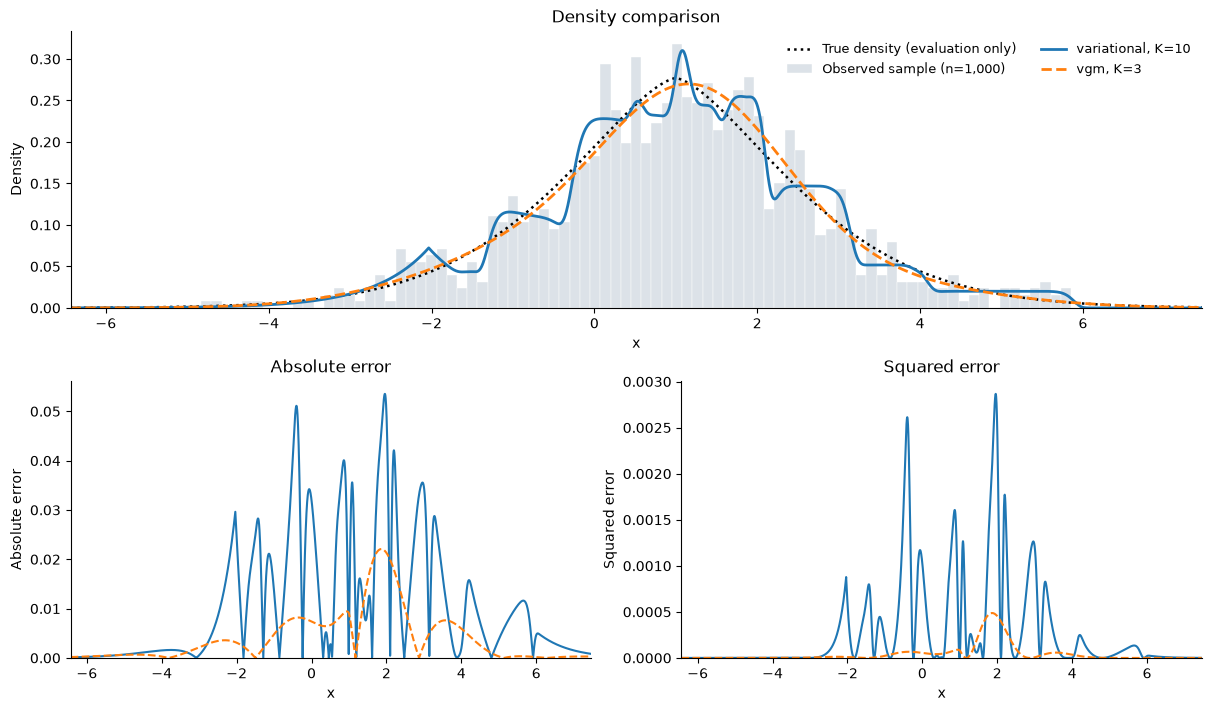

그림은 표본 주변 표시 구간입니다. IAE/ISE는 별도 적분에서 구하며 꼬리 상한과 수치오차는 result['methods'][이름]['metrics']에 있습니다.
라이브러리 버전: {'python': '3.14.7', 'numpy': '2.5.3', 'scipy': '1.18.1', 'scikit-learn': '1.9.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}
실험: ten-component stress | n=5,000 | seed=20260919 | run=2026-10-02T14:42:05.008808+00:00
LL_train↑: 같은 추정 표본의 로그우도. IAE/ISE↓: 참 밀도를 아는 경우의 적분오차.
Fit_s: 새 객체 생성·초기화·선택·적합 전체 시간. Evaluation_s: 사후 검사/오차 계산 시간.


,Algorithm,Method,K,Density_params,Selection_score,Score,LL_train,IAE,ISE,Fit_s,Evaluation_s,Converged,Search_complete,At_cap,Integral_OK,Mass_OK,Fit_status,Evaluation_status,Stop_reason
0,variational,Variational GGMM active,10,39,ELBO↑,-17152.6,-16948.8,0.0740804,0.000312125,69.3942,0.131387,True,None,True,True,True,converged,ok,ELBO_gain_per_observation
1,vgm,VGM active,9,26,Library lower_bound↑,-13663.9,-17526,0.323755,0.00343522,0.612963,0.10145,True,None,False,True,True,converged,ok,tolerance


공통 검사: 입력 보존·파라미터 조건·가중치 합·밀도 적분


,Algorithm,Input_OK,Parameters_OK,Weight_sum,min_a,min_b,max_b,Density_integral
0,variational,True,True,1,0.891119,1.33151,4.07239,1
1,vgm,True,True,1,1.06654,2,2,1


g(x;mu,a,b) = b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)
참 분포 (평가용): 0.06 g(x; -18, 1, 1.2) + 0.08 g(x; -14, 1.2, 2) + 0.1 g(x; -10, 1.4, 3) + 0.12 g(x; -6, 1, 4) + 0.14 g(x; -2, 1.3, 6) + 0.14 g(x; 2, 1.1, 1.5) + 0.12 g(x; 6, 1.5, 2.5) + 0.1 g(x; 10, 1.2, 5) + 0.08 g(x; 14, 1, 8) + 0.06 g(x; 18, 1.4, 3.5)
variational 추정식: 0.0602212 g(x; -17.989, 1.18344, 1.33151) + 0.0736604 g(x; -13.9164, 1.3021, 2.63843) + 0.104357 g(x; -9.99414, 1.43381, 3.04158) + 0.126537 g(x; -6.00511, 0.967627, 3.28012) + 0.129914 g(x; -2.02104, 1.268, 4.07239) + 0.144393 g(x; 2.06268, 1.16982, 1.57338) + 0.117809 g(x; 6.05824, 1.57062, 3.10476) + 0.102729 g(x; 9.96687, 1.21999, 3.9704) + 0.0814401 g(x; 13.9794, 0.891119, 3.43374) + 0.0589398 g(x; 18.0033, 1.34387, 3.1296)
vgm 추정식: 0.121441 g(x; 5.9409, 1.66788, 2) + 0.0782228 g(x; 13.9259, 1.59986, 2) + 0.136275 g(x; 2.04347, 1.35571, 2) + 0.125353 g(x; -5.98789, 1.06654, 2) + 0.146709 g(x; -15.205, 3.94079, 2) + 0.103951 g(x; 9.90677, 1.47686, 2) + 0.0636397 g(x; 1

...

variational: b는 점추정이며 표시 밀도는 파라미터 plug-in입니다. 유효 가중치 기준과 사전분포에 의존합니다.
variational 선택/학습 경로


,iteration,elbo,log_likelihood,active_K,seconds
0,0,-17603.7,-17218.9,10,0.0390664
1,1,-17185,-16970.5,10,1.13241
2,2,-17156.6,-16952.6,10,1.96794
3,3,-17153.9,-16950.7,10,2.86094
4,4,-17153.4,-16950,10,3.41365
5,5,-17153.1,-16949.6,10,3.98246
6,6,-17152.9,-16949.4,10,4.5523
7,7,-17152.8,-16949.2,10,5.18808
8,8,-17152.7,-16949.1,10,5.70666
9,9,-17152.7,-16949,10,6.20868


vgm: 독립 비교 모델. 유효 성분만 남겨 가중치를 재정규화합니다. 그 적합값은 GGMM에 전달하지 않습니다.
vgm 선택/학습 경로


""


Search_complete는 기록된 탐색의 완료 여부이며 전역 최적 K의 보장이 아닙니다. None은 해당 판정이 없거나 미보고입니다.
서로 다른 이름의 선택 점수는 직접 비교하지 않습니다. Density_params는 표시 밀도의 명목 파라미터 수이며 변분 사후분포의 차원과 다릅니다.


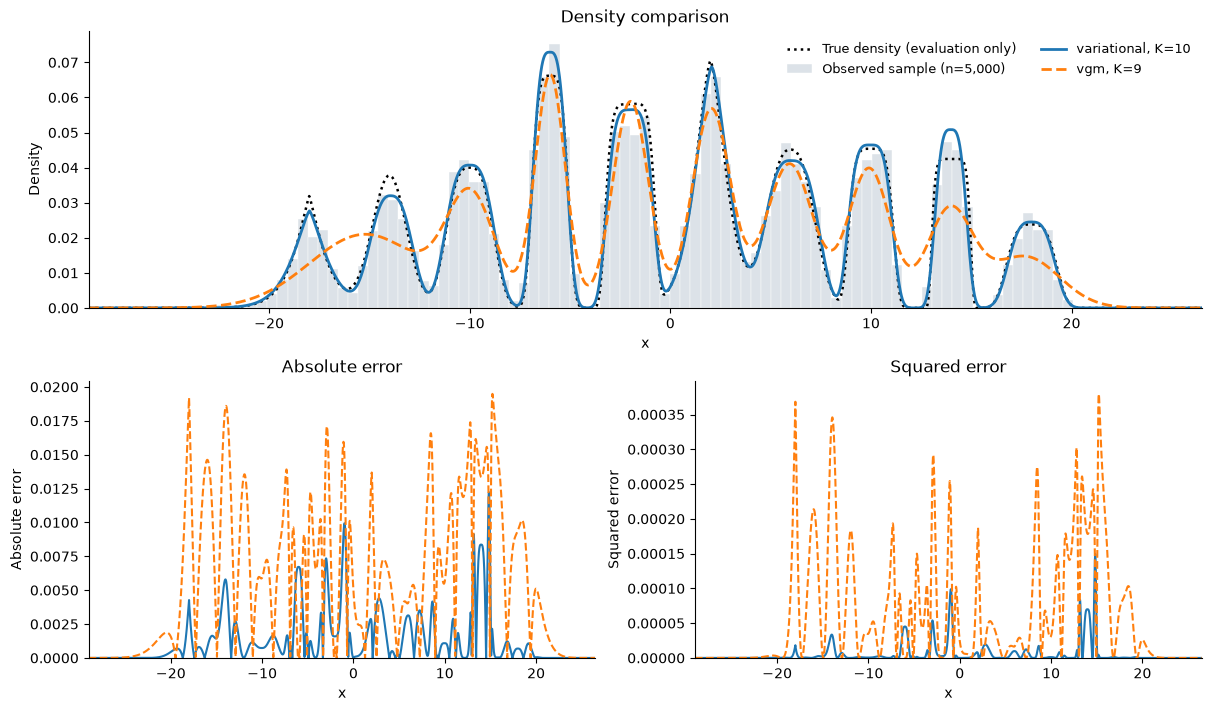

그림은 표본 주변 표시 구간입니다. IAE/ISE는 별도 적분에서 구하며 꼬리 상한과 수치오차는 result['methods'][이름]['metrics']에 있습니다.
라이브러리 버전: {'python': '3.14.7', 'numpy': '2.5.3', 'scipy': '1.18.1', 'scikit-learn': '1.9.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}


In [ ]:
# 선택 실험 2: 같은 검사 형식을 단일 GGD와 참 K=10 사례에도 적용합니다.
# 기본 False. True로 바꾸면 각 사례를 새로 생성·적합하고 표·그림을 함께 표시합니다.
# 참 K=10에서 기존 split/tree 방법이 실패할 수 있으며, 실패/미완료 상태를 그대로 보고합니다.
RUN_EXTRA_CASES = True
if RUN_EXTRA_CASES:
    cases = [
        ("single-GGD control", Mixture([1.], [1.], [2.], [1.5]), 1000, 20261002),
        ("ten-component stress", Mixture(
            [.06,.08,.10,.12,.14,.14,.12,.10,.08,.06],
            [-18,-14,-10,-6,-2,2,6,10,14,18],
            [1.,1.2,1.4,1.,1.3,1.1,1.5,1.2,1.,1.4],
            [1.2,2.,3.,4.,6.,1.5,2.5,5.,8.,3.5]), 5000, 20260919),
    ]
    extra_results = {}
    for case_name, case_truth, case_n, case_seed in cases:
        case_x = sample_mixture(case_truth, case_n, case_seed)
        case_result = run_experiment(case_x,
            {name: ALGORITHMS[name] for name in METHODS}, truth=case_truth,
            seed=case_seed, checks=CHECKS, title=case_name)
        extra_results[case_name] = case_result
        show_experiment(case_result, histories=True)
else:
    print("미실행: 추가 사례는 RUN_EXTRA_CASES=True로 설정하세요.")


## 12. 선택 실험 3 — 실제 연속형 열

실험: observed continuous column | n=5,000 | seed=None | run=2026-10-02T13:43:43.212996+00:00
LL_train↑: 같은 추정 표본의 로그우도. IAE/ISE↓: 참 밀도를 아는 경우의 적분오차.
Fit_s: 새 객체 생성·초기화·선택·적합 전체 시간. Evaluation_s: 사후 검사/오차 계산 시간.


,Algorithm,Method,K,Density_params,Selection_score,Score,LL_train,IAE,ISE,Fit_s,Evaluation_s,Converged,Search_complete,At_cap,Integral_OK,Mass_OK,Fit_status,Evaluation_status,Stop_reason
0,split,Split GGMM,3,11,BIC↓,24448.3,-12177.3,NaN,NaN,5.94044,0.0059446,True,True,False,True,True,converged,ok,no_BIC_improving_split
1,vgm,VGM active,5,14,Library lower_bound↑,-7914.25,-12270.4,NaN,NaN,0.66363,0.0070721,True,None,False,True,True,converged,ok,tolerance


공통 검사: 입력 보존·파라미터 조건·가중치 합·밀도 적분


,Algorithm,Input_OK,Parameters_OK,Weight_sum,min_a,min_b,max_b,Density_integral
0,split,True,True,1,1.19198,1.50534,8.8418,1
1,vgm,True,True,1,0.857474,2,2,1


g(x;mu,a,b) = b/[2a Gamma(1/b)] exp(-|(x-mu)/a|^b)
split 추정식: 0.201692 g(x; -4.98821, 1.19198, 1.50534) + 0.306708 g(x; 0.0284717, 1.58605, 3.89673) + 0.4916 g(x; 5.99336, 2.02321, 8.8418)
vgm 추정식: 0.263282 g(x; 6.86734, 1.006, 2) + 0.228738 g(x; 5.00264, 0.916989, 2) + 0.191711 g(x; -0.495586, 1.05004, 2) + 0.20009 g(x; -5.00703, 1.45066, 2) + 0.116179 g(x; 0.851692, 0.857474, 2)
성분 파라미터: a는 척도, sigma_derived는 a와 b에서 계산한 표준편차입니다.


...

split: K=1에서 분할하고 모든 성분을 재적합하는 기존 프로토타입. 미수렴 분할이 있으면 탐색 미완료로 표시합니다.
split 선택/학습 경로


,finite,converged,iterations,nfev,attempts,message,best_is_endpoint,solver_success,stationarity_checked,gradient_check_tolerance,rejected_steps,seconds,log_likelihood,BIC,projected_gradient,a_floor_hits,min_b,max_b,K,split_parent,split_method,moment_fallbacks,step,accepted,from_K,nested_density_max_log_error,delta_LL,delta_BIC,likelihood_below_parent
0,True,True,11,14,1,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,True,True,True,0.0001,0,0.0180499,-13777.3,27580.1,1.99731e-06,0,13.8769,13.8769,1,NaN,one_component,1,0,True,NaN,NaN,NaN,NaN,NaN
1,True,True,29,35,1,CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL,True,True,True,0.0001,0,0.120418,-12735.9,25531.5,9.16076e-06,0,7.45428,8.84181,2,1,weighted_lloyd,1,1,True,1,4.44089e-16,1041.35,-2048.62,False
2,True,True,41,46,1,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH,True,True,True,0.0001,0,0.138081,-12177.3,24448.3,2.18925e-05,0,1.50534,8.8418,3,1,weighted_lloyd,0,2,True,2,1.77636e-15,558.622,-1083.18,False


vgm: 독립 비교 모델. 유효 성분만 남겨 가중치를 재정규화합니다. 그 적합값은 GGMM에 전달하지 않습니다.
vgm 선택/학습 경로


""


Search_complete는 기록된 탐색의 완료 여부이며 전역 최적 K의 보장이 아닙니다. None은 해당 판정이 없거나 미보고입니다.
서로 다른 이름의 선택 점수는 직접 비교하지 않습니다. Density_params는 표시 밀도의 명목 파라미터 수이며 변분 사후분포의 차원과 다릅니다.


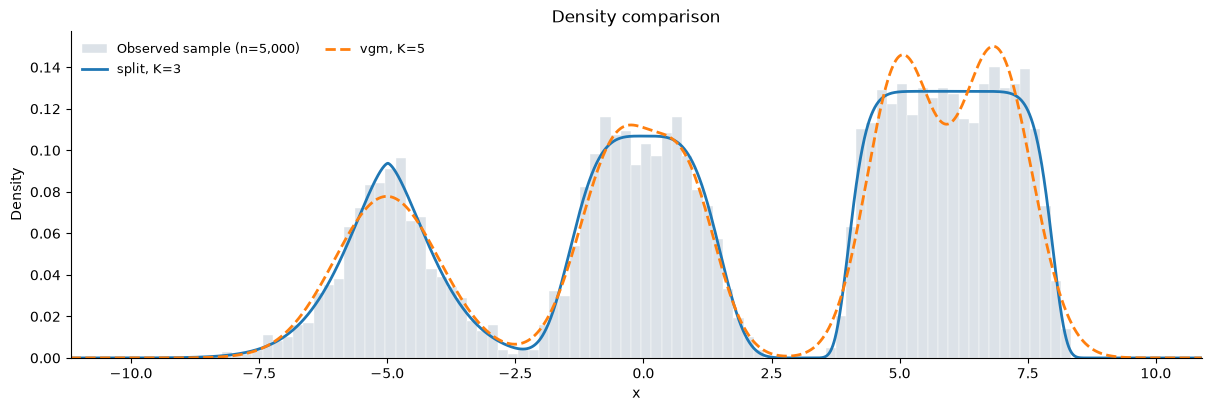

그림은 표본 주변 표시 구간입니다. IAE/ISE는 별도 적분에서 구하며 꼬리 상한과 수치오차는 result['methods'][이름]['metrics']에 있습니다.
라이브러리 버전: {'python': '3.14.7', 'numpy': '2.5.3', 'scipy': '1.18.1', 'scikit-learn': '1.9.1', 'pandas': '3.0.5', 'matplotlib': '3.11.2'}


In [ ]:
# 선택 실험 3: 사용자가 제공한 실제 연속형 열도 같은 형식으로 검사합니다.
# 참 밀도가 없으므로 IAE/ISE는 NaN입니다. 훈련 LL을 예측 성능으로 해석하지 않습니다.
# 예: REAL_X = dataframe["연속형 열 이름"].dropna().to_numpy()
RUN_REAL_COLUMN = True
if RUN_REAL_COLUMN:
    real_result = run_experiment(X, {name: ALGORITHMS[name] for name in METHODS},
        truth=None, checks=CHECKS, title="observed continuous column")
    show_experiment(real_result, histories=True)
else:
    print("미실행: 실제 열을 REAL_X에 넣고 RUN_REAL_COLUMN=True로 설정하세요.")
